# **PROJECT : PREDICTION BANK MARKETING BY CRISP-DM** 

# **I. COMPREHENSION DU CONTEXTE ET DES DONNEES**

## **1- Analyse des objectifs stratégiques de la banque**

La banque dans notre contexte mène des campagnes marketing téléphoniques pour vendre des dépôts à terme (investissements ou épargne bancaires bloquée sur une certaine durée). C'est l'un des produits financiers entrant dans la stabilité et la rentabilité de cette dernière. Son ojectif est de maximiser le nombre de souscriptions (y = yes) tout en réduisant les coûts.
Notre objectif ici sera de **Prédire si un client va accepter (yes) ou refuser (no)**. Ainsi il faut que nous segmenter les clients selon leur pouvoir d'achat pour:

**a)- Contacter en priorité ceux qui ont une haute probabilité de dire yes.**

**b)- Réduire le coût des campagnes (factures téléphoniques et frais annexes).**

**c)- Augmenter le ROI marketing (Retour Sur Investissement).**

## **2) Exploration des données disponibles**

### **A) CALLING PACKAGES**

In [107]:
# Install xgboost if not already installed
%pip install xgboost
%pip install -U scikit-learn
%pip install shap
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [108]:
#Bibliothèques pour analyses de données
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Bibliothèques pour TEST Statistiques
import scipy.stats as stats
import warnings

# Bibliothèques pour implémentation du modèle ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,cohen_kappa_score, matthews_corrcoef, roc_auc_score,confusion_matrix)
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


# Bibliothèques pour voir l'importance des variables dans un modèle
%pip install shap
import shap
from yellowbrick.model_selection import FeatureImportances


# Ignorer les warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


### **B) OPENING DATASET**

In [109]:
#Importation de la base de données et affichage des premières lignes
df = pd.read_csv("D:/Users/Sanpsy/Desktop/Aloyas files/Project Classify Bank Marketing/bank-additional-full.csv", sep=';',low_memory=False)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [110]:
# Affichage des dimensions de la base de données
df.shape

(41188, 21)

**Interprètation** :  La base de données est constituée de 41188 lignes et 21 colonnes correspondantes auxx variables.

In [111]:
# Affichage des variables de la base de données
for col in df.columns:
    print(col)

age
job
marital
education
default
housing
loan
contact
month
day_of_week
duration
campaign
pdays
previous
poutcome
emp.var.rate
cons.price.idx
cons.conf.idx
euribor3m
nr.employed
y


**Interprètation : Nous avons 21 variables**

### **C) VARIABLES QUI NOUS INTERRESSENT**

In [112]:
# 2.droping variables unwanted
variables_a_supprimer = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]
df = df.drop(columns=variables_a_supprimer)

**Interprétation :** **De ces 21 variables nous avons décider d'utiliser les plus pertienetes à savoir:**

- **1. emp.var.rate** : Taux de variation de l'emploi (en pourcentage) — indicateur économique du marché du travail. Un taux positif indique une création nette d'emplois, tandis qu'un taux négatif indique une perte nette. (numérique).

- **2. cons.price.idx** : Indice des prix à la consommation (IPC) — mesure du niveau moyen des prix des biens de consommation (numérique).

- **3. cons.conf.idx** : Indice de confiance des consommateurs — reflète l'optimisme ou le pessimisme des consommateurs par rapport à l'économie future. (numérique).

- **4. euribor3m** : Taux interbancaire offert en euros à 3 mois — taux d'intérêt auquel les banques européennes se prêtent de l'argent entre elles pour une durée de 3 mois (numérique).

- **5. nr.employed** : Nombre d'employés — indicateur du niveau global de l'emploi dans l'économie (souvent exprimé sous forme d'indice ou de grande valeur, pas un nombre brut), (numérique).


In [113]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,yes


**Interprètation :** 

In [114]:
# Afficher les valeurs uniques pour chaque colonne
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Valeurs uniques dans la colonne '{col}': {unique_values}")

Valeurs uniques dans la colonne 'age': [56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
Valeurs uniques dans la colonne 'job': ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
Valeurs uniques dans la colonne 'marital': ['married' 'single' 'divorced' 'unknown']
Valeurs uniques dans la colonne 'education': ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
Valeurs uniques dans la colonne 'default': ['no' 'unknown' 'yes']
Valeurs uniques dans la colonne 'housing': ['no' 'yes' 'unknown']
Valeurs uniques dans la colonne 'loan': ['no' 'yes' 'unknown']
Valeurs uniques dans la colonne 'contact': ['telephone' 'cellular']
Valeurs uniques dans la c

**Interprètation** : pas pertinente cette interpretation

In [115]:
#Affichage des types de données de chaque colonne.
df.dtypes

age             int64
job            object
marital        object
education      object
default        object
housing        object
loan           object
contact        object
month          object
day_of_week    object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

**Interprètation** : Nous observons ici 11 variables object donc qui sont sous forme d'objet c'est aà dire des textes et 10 variables numériques dont 5 qui sont des nombres décimaux.

### **D) STATISTIQUES DESCRIPTIVES**

In [116]:
df.describe()

,age,duration,campaign,pdays,previous
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963
std,10.42125,259.279249,2.770014,186.910907,0.494901
min,17.00000,0.000000,1.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000


**Interpretation:** 

**1- emp.var.rate (Taux de variation de l'emploi)**
Nous observons une  moyenne autour de 0.08 (lignes 1 et 2), avec des exemples à -3.4, -1.8. Un taux d'emploi négatif (ex: -3.4%) indique un contexte économique difficile, ce qui peut réduire l'intérêt des clients pour bloquer leur argent dans des produits financiers comme des dépôts à terme contrairement au taux positif  qui traduit une croissance économique et peut rendre les clients plus confiants et plus disposés à investir.

**2- cons.price.idx (Indice des prix à la consommation)**
Nous avons des valeurs comprises entre 93.5 et 92.2 : Un indice élevé signale de l'inflation. En période d'inflation, les dépôts à terme peuvent paraître moins attractifs (car leur rendement est fixé et pourrait être dépassé par la hausse des prix).Cependant, certains clients préfèrent sécuriser leur capital dans des produits garantis, ce qui pourrait augmenter l'acceptation dans certains segments.

**3- cons.conf.idx (Indice de confiance des consommateurs)**
Les valeurs sont souvent négatives (ex: -40.5, -50.8, -42.7). Un indice de confiance très bas indique que les consommateurs sont pessimistes sur l'avenir économique. Cela peut pousser certaines personnes à ne pas investir ou à chercher des produits très sûrs comme le dépôt à terme.

**4- euribor3m (Taux interbancaire européen à 3 mois)**
On touve des exemples autour de 3.62%, 0.63%, 1.34%.
Un euribor élevé signifie que le coût de l'argent est élevé → les banques peuvent proposer des taux d'intérêt plus élevés sur les dépôts, rendant le dépôt à terme plus attractif. À l'inverse, un euribor bas rend ces produits moins intéressants.

**5- nr.employed (Nombre d'employés dans l'économie)**
Ici grandes valeurs comme 5167, 4963, 5099. Un nombre élevé d'employés traduit une économie en bonne santé. Dans ce cas, les clients sont plus confiants pour souscrire à des produits financiers sur le moyen/long terme comme les dépôts à terme. 

**En ce qui concerne les autres variables nous avons :**

**L'âge du client :** avec une moyenne de 40 ans et un Écart-type de 10.4. Les clients ont en moyenne 40 ans, un âge propice à l’investissement. Les très jeunes (17–25) peuvent être moins enclins à s’engager, tandis que les plus âgés (50+) sont souvent à la recherche de sécurité, ce qui les rend potentiellement plus réceptifs aux dépôts à terme.

**previous :** est la variiable relative au nombre de contacts lors de campagnes précédentes avec une moyenne de 0.17 et un écart-type : 0.49
 Le Minimum = 0  et le Maximum = 7	montre que La plupart des clients n’ont jamais été contactés auparavant (valeur = 0). Ceux ayant déjà été en contact plusieurs fois (jusqu’à 7) peuvent soit être intéressés, soit fatigués par la sollicitation.

**duration :** Traduisant la durée des appels emis (en secondes) dans le cadre de cette campagne marketing. Nous observons une moyenne de 258s soit environs (~4 min) et un écart-type : 259s. Le Minimum est de : 0s et le Maximum est de 4918s soit (~82 min): Plus un appel est long, plus le client semble intéressé.

**campaign :** est le nombre de contacts effectués pendant la campagne sur un client donné	avec une moyenne de 2.57 et l'écart-type est de 2.77. En général, les clients sont contactés 2 à 3 fois. Un trop grand nombre de tentatives (jusqu'à 56 !) comme le montre le maximum de cette variable peut indiquer de la résistance, voire du rejet.

In [117]:
# Séparer variables catégorielles et numériques
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Tableau pour les variables catégorielles

cat_results = []

for var in categorical_vars:
    counts = df[var].value_counts(dropna=False)
    percents = df[var].value_counts(normalize=True, dropna=False) * 100
    temp_df = pd.DataFrame({
        'Variable': var,
        'Modalité': counts.index,
        'n': counts.values,
        '%': percents.round(2).values
    })
    cat_results.append(temp_df)

# Regrouper tous les résultats dans un seul DataFrame
cat_results_df = pd.concat(cat_results, ignore_index=True)

#Tableau pour les variables numériques

num_results_df = df[numerical_vars].agg(['mean', 'std']).T.reset_index()
num_results_df.columns = ['Variable', 'Mean', 'SD']
num_results_df['Mean'] = num_results_df['Mean'].round(2)
num_results_df['SD'] = num_results_df['SD'].round(2)

# Affichage final

print("\nTableau : Variables catégorielles")
display(cat_results_df)

print("\nTableau : Variables numériques")
display(num_results_df)


Tableau : Variables catégorielles


,Variable,Modalité,n,%
0,job,admin.,10422,25.30
1,job,blue-collar,9254,22.47
2,job,technician,6743,16.37
3,job,services,3969,9.64
4,job,management,2924,7.10
5,job,retired,1720,4.18
6,job,entrepreneur,1456,3.54
7,job,self-employed,1421,3.45
8,job,housemaid,1060,2.57
9,job,unemployed,1014,2.46



Tableau : Variables numériques


,Variable,Mean,SD
0,age,40.02,10.42
1,duration,258.29,259.28
2,campaign,2.57,2.77
3,pdays,962.48,186.91
4,previous,0.17,0.49


**Interprétation** : Pas pertinente ou je ne sais pas quoi interpreter là. La base de donnée a été divisé en deux partie. Les variables catégorielles et les variables numériques

### **E- VISUALISATION UNIVARIEE DES DONNEES**

#### **1) Variables quantitatives ou continues**

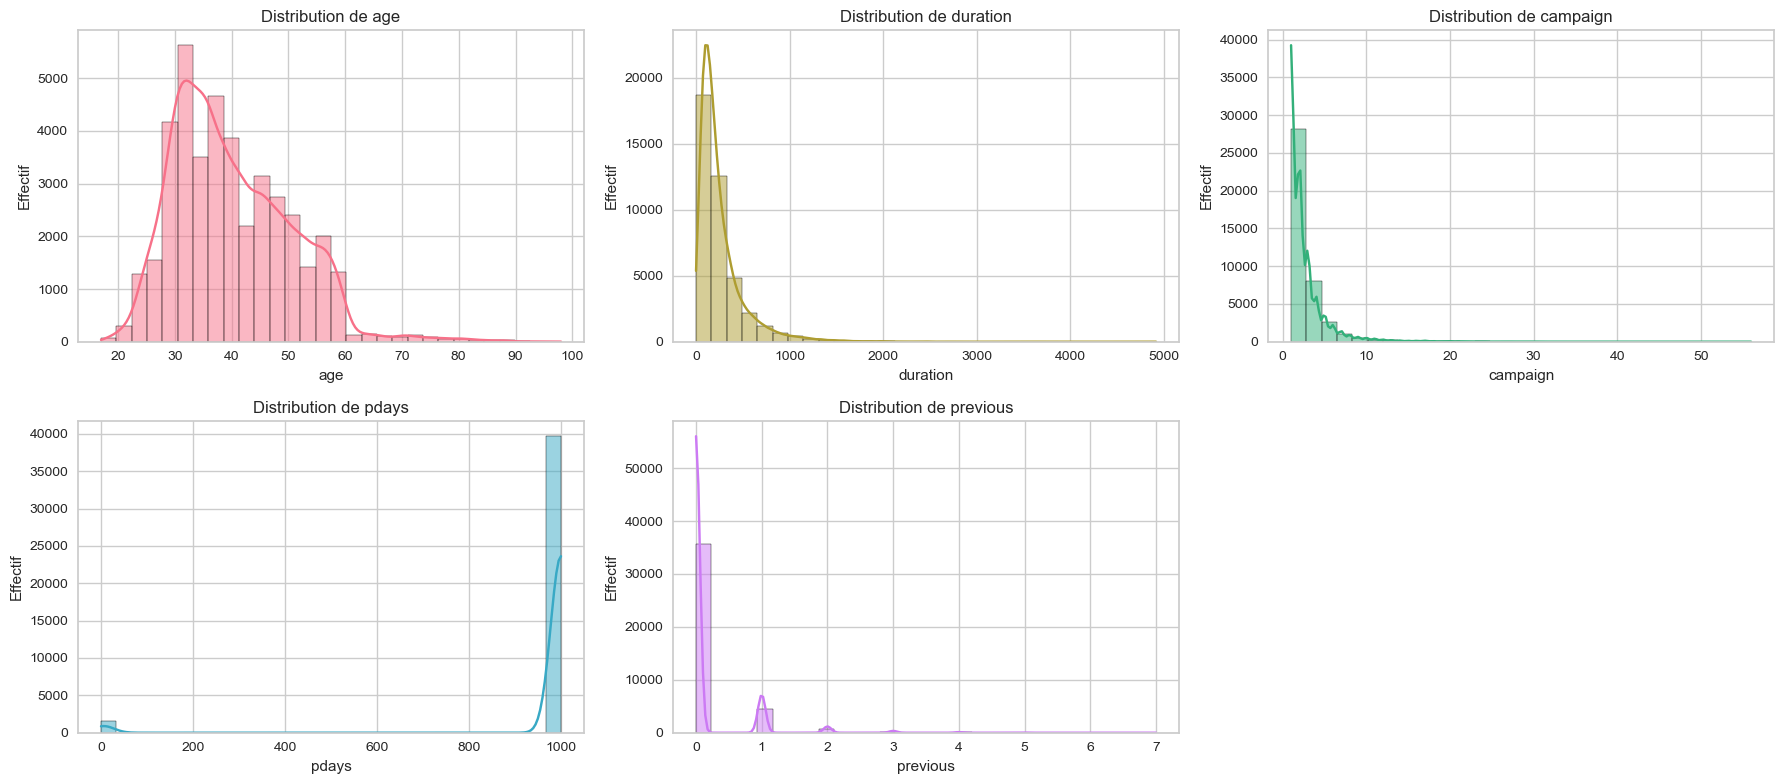

In [118]:
# 1. Liste des variables numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Palette de couleurs
colors = sns.color_palette("husl", len(num_vars))

# 3. Initialiser la figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # Ajuste si tu veux plus ou moins de colonnes
axes = axes.flatten()

# 4. Boucle sur chaque variable numérique
for i, var in enumerate(num_vars):
    sns.histplot(df[var], kde=True, bins=30, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Effectif')

# 5. Supprimer les subplots vides
if len(num_vars) < len(axes):
    for j in range(len(num_vars), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interprètation :** Les diifférentes visualisations nous montre que approxiamtivement plus de 6000 clients ont un **Age** compris entre 30 et 33 ans ce qui témoigne de la jeunesse de la clientèle cible pour permettre d'avoir des durées plus longues sur les DAT; Environs 20.000 clients ont passê plus de 200 secondes comme **Durée** au téléphone lors des appels de leur chargé de clientèle dans le cadre cette camapagne marketing; Près de 28.000 clients ont été appelé au moins 2 aà 3 fois : **Distribution de Campaign**; la majorité des cliients de la base de données soit environs 40.000 n'ont jamais été appelé auparavant pour cette offre et cette camapagne, cela augmente les chances de receptivité des clients : **Distribution pdays**. 

#### **2) Variables qualitatives ou catégorielles**

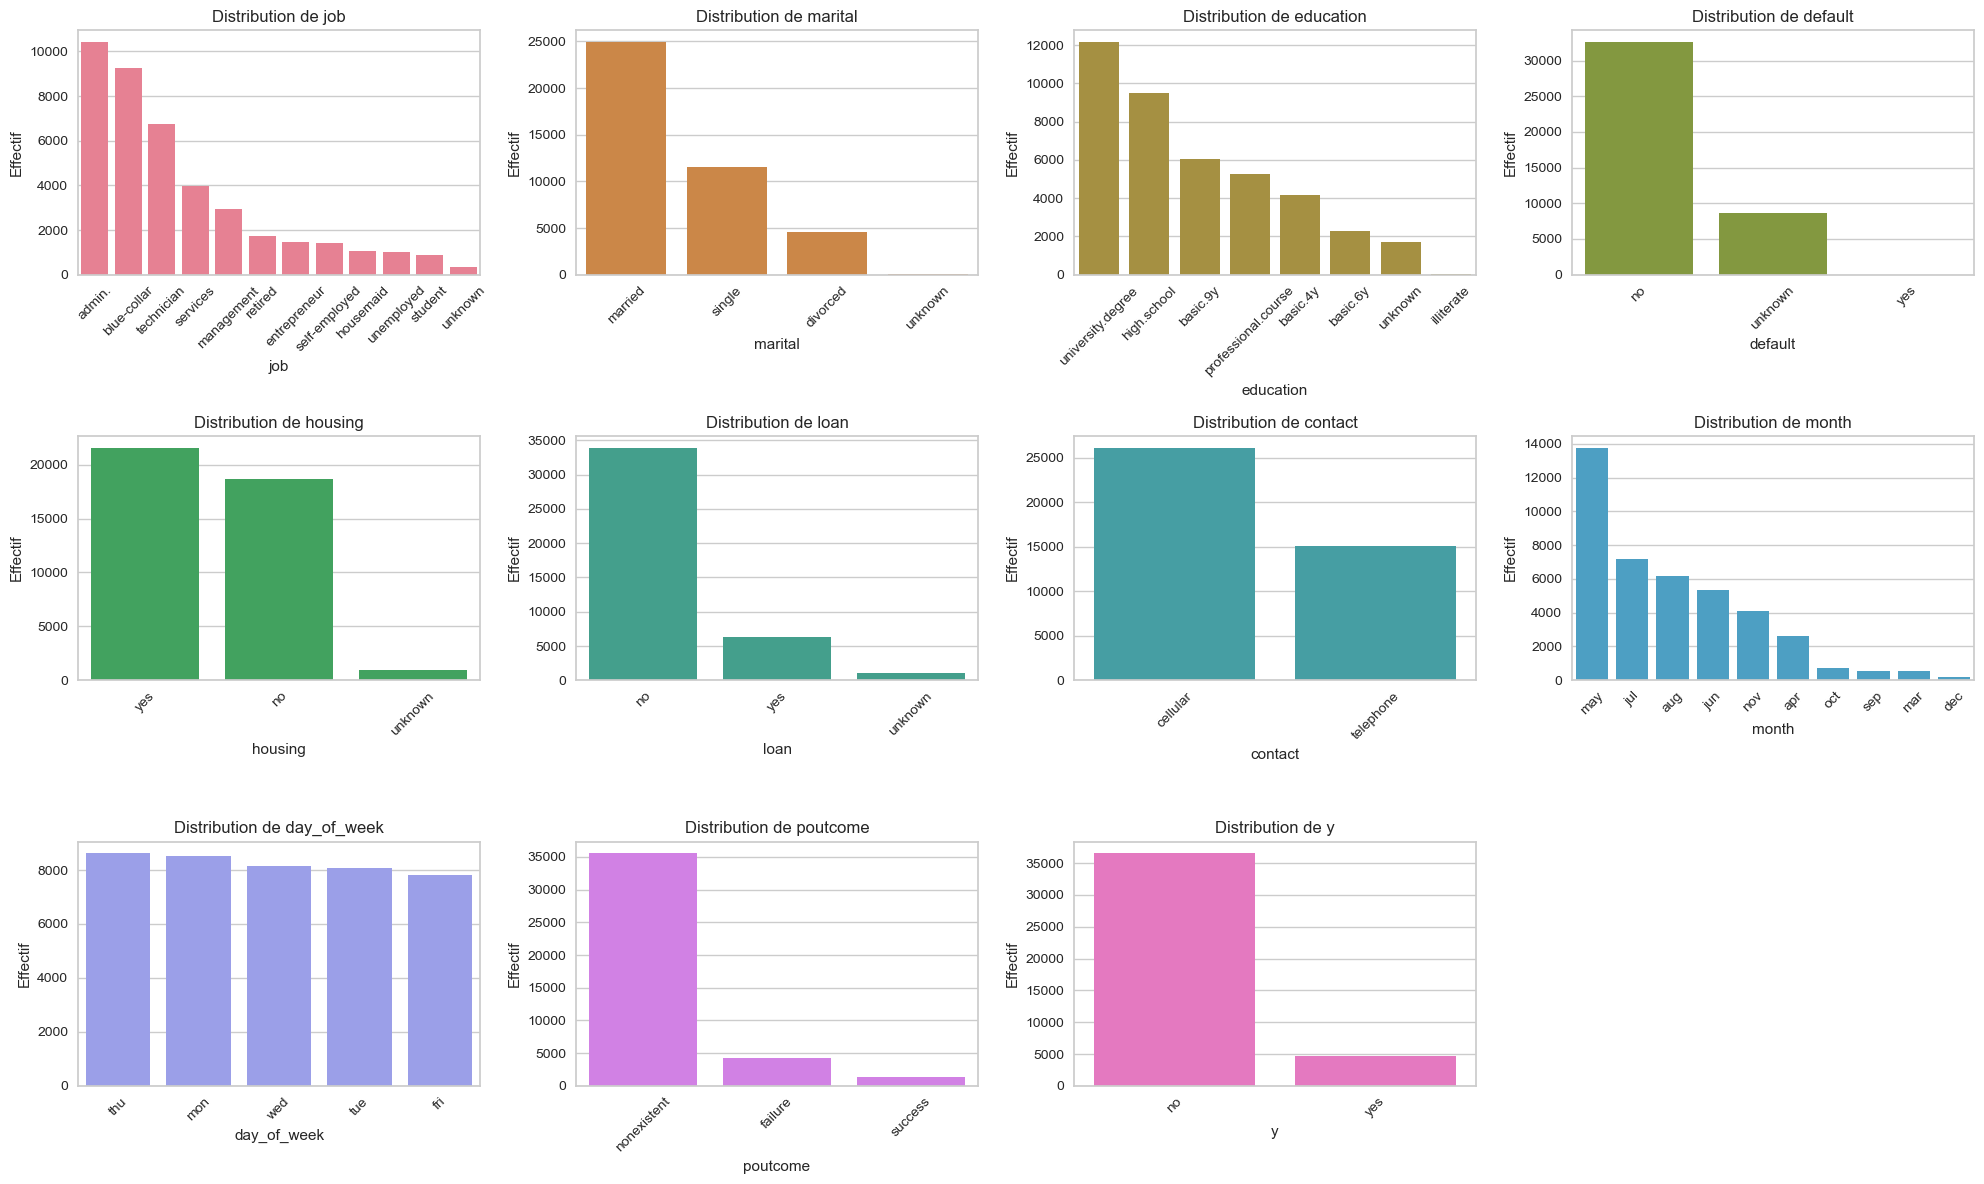

In [119]:
# 1. Liste des variables catégorielles
cat_vars = df.select_dtypes(include=['object']).columns.tolist()

# 2. Palette de couleurs
colors = sns.color_palette("husl", len(cat_vars))

# 3. Initialiser la figure
fig, axes = plt.subplots(3, 4, figsize=(20, 12))  # Ajusté pour plus de catégorielles
axes = axes.flatten()

# 4. Boucle sur chaque variable catégorielle
for i, var in enumerate(cat_vars):
    sns.countplot(data=df, x=var, palette=[colors[i]], ax=axes[i], order=df[var].value_counts().index)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Effectif')
    axes[i].tick_params(axis='x', rotation=45)

# 5. Supprimer les subplots vides
if len(cat_vars) < len(axes):
    for j in range(len(cat_vars), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Interpretation** Pas de pertinence, les visualisations sont claires donc pas besoin de les interpreter 

### **F- VISUALISATION BIVARIEE DES DONNEES**

#### **1) Boxplots croisés avec notre outcome**

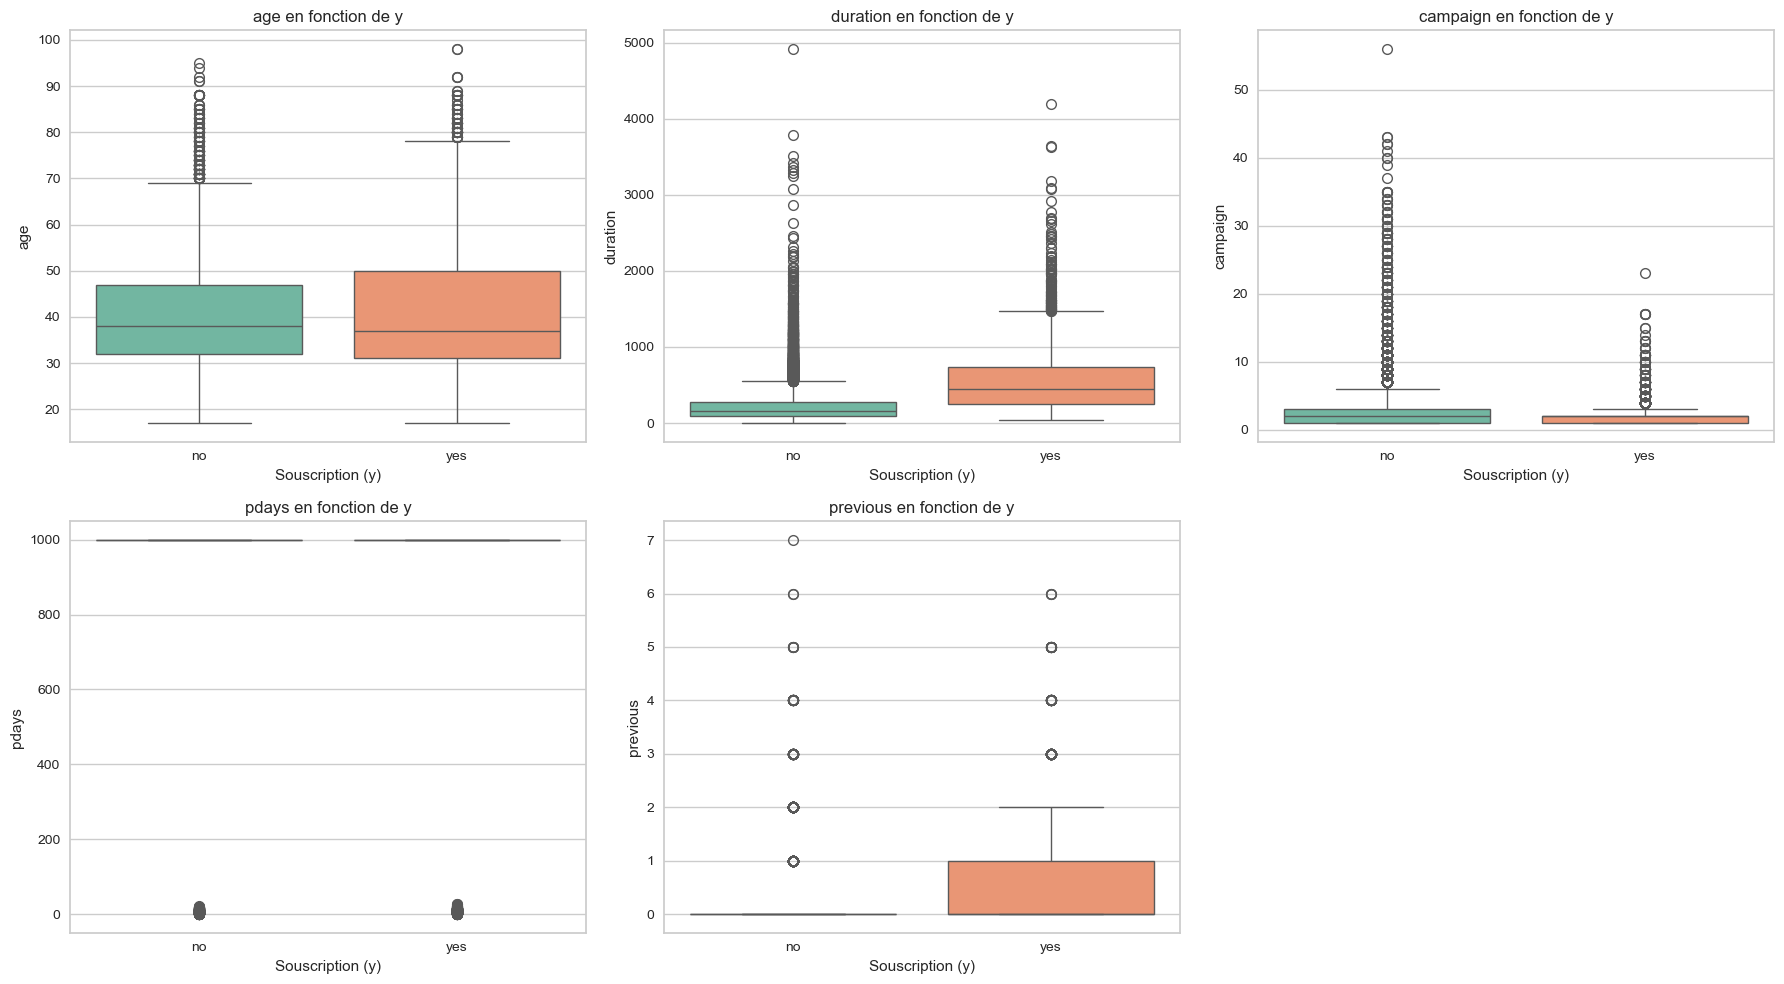

In [120]:
# Liste des variables numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Retirer 'y' si jamais il est dedans par erreur
if 'y' in num_vars:
    num_vars.remove('y')

# Palette de couleurs
colors = sns.color_palette("Set2", len(num_vars))

# Initialiser la figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Ajuste selon le nombre de variables
axes = axes.flatten()

# Boucle sur chaque variable numérique
for i, var in enumerate(num_vars):
    sns.boxplot(x='y', y=var, data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f'{var} en fonction de y')
    axes[i].set_xlabel('Souscription (y)')
    axes[i].set_ylabel(var)

# Supprimer les subplots vides si besoin
if len(num_vars) < len(axes):
    for j in range(len(num_vars), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interprètation :**

#### **2) HEATMAP**

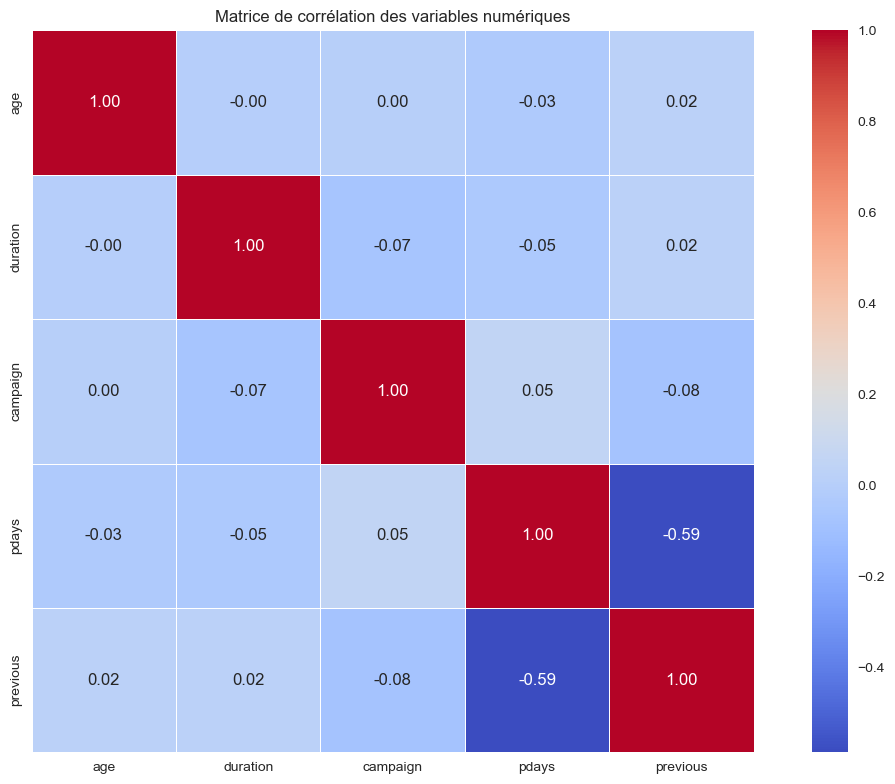

In [121]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

**Interprètation :** Nous oberservons une correlation négative (-0,59)  entre le nombre de contact lors de la campagne précedente dont le minimum est 0 et le nombre de jours depuis le dernier contact précédent qui est de 999 jours et qui montre qu'il n'y a pas eu de contact.

## **3) Identification des segments à cibler en priorité**

In [122]:
# Variables que tu veux utiliser
selected_vars = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y']

# Sous-ensemble du dataframe
df_segmentation = df[selected_vars]

# Variables numériques
numerical_vars = ['age']

# Variables catégorielles
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan']

In [123]:
# Analyser les variables catégorielles
for var in categorical_vars:
    print(f"\n--- Variable : {var} ---")
    cross_tab = pd.crosstab(df_segmentation[var], df_segmentation['y'], normalize='index') * 100
    cross_tab = cross_tab.reset_index()
    display(cross_tab)


--- Variable : job ---


y,job,no,yes
0,admin.,87.027442,12.972558
1,blue-collar,93.105684,6.894316
2,entrepreneur,91.483516,8.516484
3,housemaid,90.000000,10.000000
4,management,88.782490,11.217510
5,retired,74.767442,25.232558
6,self-employed,89.514426,10.485574
7,services,91.861930,8.138070
8,student,68.571429,31.428571
9,technician,89.173958,10.826042



--- Variable : marital ---


y,marital,no,yes
0,divorced,89.679098,10.320902
1,married,89.842747,10.157253
2,single,85.995851,14.004149
3,unknown,85.000000,15.000000



--- Variable : education ---


...

y,default,no,yes
0,no,87.121026,12.878974
1,unknown,94.847040,5.152960
2,yes,100.000000,0.000000



--- Variable : housing ---


y,housing,no,yes
0,no,89.120395,10.879605
1,unknown,89.191919,10.808081
2,yes,88.380608,11.619392



--- Variable : loan ---


y,loan,no,yes
0,no,88.659794,11.340206
1,unknown,89.191919,10.808081
2,yes,89.068502,10.931498


**Interprètation :** Je ne sais pas quoi interpreter 

In [124]:
# Statistiques de 'age' par 'y'
age_stats = df_segmentation.groupby('y')['age'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
display(age_stats)


,mean,std,min,max,count
y,,,,,
no,39.91,9.90,17,95,36548
yes,40.91,13.84,17,98,4640


**Interprèation**

# **II. PREPARATION DES DONNEES**

### **A) Traitement des valeurs manquantes**

In [125]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,yes


In [126]:
# Calcul du nombre et du pourcentage de valeurs manquantes
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

# Regrouper dans un DataFrame pour affichage clair
missing_report = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percent
})

# Filtrer uniquement les colonnes qui ont des valeurs manquantes
missing_report = missing_report[missing_report['Missing Count'] > 0]

# Afficher
print(missing_report)


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Interpretation**

### **B) Traitement des outliers**

#### **1) Par la méthode IQR**

In [127]:
# Liste des variables numériques
numerical_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Dictionnaire pour stocker les résultats
outliers_iqr = {}

# Boucle sur chaque variable numérique
for var in numerical_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Détecter les outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    
    # Stocker le résultat
    outliers_iqr[var] = len(outliers)

# Affichage
print("\nNombre d'outliers détectés par IQR pour chaque variable :")
for var, count in outliers_iqr.items():
    print(f"{var} : {count} outliers")



Nombre d'outliers détectés par IQR pour chaque variable :
age : 469 outliers
duration : 2963 outliers
campaign : 2406 outliers
pdays : 1515 outliers
previous : 5625 outliers


**Interprétation :**  Pour la variable **age**, 469 outliers ont été détectés, correspondant à des clients très jeunes ou très âgés. Les jeunes sont souvent peu concernés par les produits d’épargne, tandis que les plus âgés peuvent rechercher des solutions sécurisées comme les dépôts à terme, ce qui en fait un segment potentiellement intéressant.

Pour la variable **duration**, 2963 valeurs sont considérées comme des outliers. Ces durées extrêmes représentent soit des appels très courts (rejet rapide), soit très longs (discussion approfondie, potentiellement synonyme d'intérêt). Cependant, cette variable étant disponible uniquement après l’appel, elle ne peut pas être utilisée pour prédire à l’avance le comportement du client.

Concernant **campaign**, 2406 clients sont considérés comme outliers car ils ont été contactés un nombre anormalement élevé de fois. Cela peut traduire une résistance à l’offre ou une stratégie de relance inefficace. Trop de sollicitations peuvent nuire à l’image de la banque et réduire la probabilité d’adhésion.

Pour la variable **pdays**, 1515 outliers ont été détectés. Ces clients ont été contactés récemment par une autre campagne (valeurs ≠ 999). Le fait d’avoir été recontacté récemment peut avoir un impact positif ou négatif selon la qualité du précédent contact, et constitue un facteur de segmentation important.

Enfin, pour **previous**, on compte 5625 outliers, correspondant à des clients ayant été contactés plusieurs fois dans des campagnes antérieures. Cela peut indiquer soit un intérêt progressif, soit une lassitude face aux sollicitations, selon le contexte. Ces profils doivent être analysés finement pour éviter un gaspillage d'efforts commerciaux.

#### **2) Par la méthode des 3 sigmats**

In [128]:
# Dictionnaire pour stocker les résultats
outliers_3sigma = {}

# Boucle sur chaque variable numérique
for var in numerical_vars:
    mean = df[var].mean()
    std = df[var].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    # Détecter les outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    # Stocker le résultat
    outliers_3sigma[var] = len(outliers)

# Affichage
print("\nNombre d'outliers détectés par la méthode des 3 sigmas pour chaque variable :")
for var, count in outliers_3sigma.items():
    print(f"{var} : {count} outliers")



Nombre d'outliers détectés par la méthode des 3 sigmas pour chaque variable :
age : 369 outliers
duration : 861 outliers
campaign : 869 outliers
pdays : 1515 outliers
previous : 1064 outliers


**Interpretation**

**CONCLUSION** :  Pour pdays, la détection est identique entre IQR et 3 sigmas. Cela veut dire que la distribution de pdays est tellement anormale que les deux méthodes arrivent au même constat.Pour les autres variables IQR détecte beaucoup plus d'outliers que 3 sigmas surtout pour duration, campaign, et previous. Cela suggère que ces variables ont des distributions très asymétriques (ex: longues traînes, non normales).La méthode IQR est plus stricte que la méthode des 3 sigmas, surtout pour des distributions non gaussiennes.

#### **3) On choisis la méthode IQR et on continue** 

In [129]:
# Liste des variables numériques
numerical_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Dictionnaire pour stocker les résultats
outliers_iqr_percentage = {}

# Nombre total d'observations
n_total = df.shape[0]

# Boucle sur chaque variable numérique
for var in numerical_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Détecter les outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    # Calcul du pourcentage
    percent_outliers = (len(outliers) / n_total) * 100

    # Stocker le résultat
    outliers_iqr_percentage[var] = round(percent_outliers, 2)

# Affichage
print("\nPourcentage d'outliers détectés par la méthode IQR pour chaque variable :")
for var, pct in outliers_iqr_percentage.items():
    print(f"{var} : {pct}%")



Pourcentage d'outliers détectés par la méthode IQR pour chaque variable :
age : 1.14%
duration : 7.19%
campaign : 5.84%
pdays : 3.68%
previous : 13.66%


In [130]:
# Liste des variables numériques
numerical_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Dictionnaire pour stocker les résultats
outliers_iqr_percentage = {}

# Nombre total d'observations
n_total = df.shape[0]

# Boucle sur chaque variable numérique
for var in numerical_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Détecter les outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    # Calcul du pourcentage
    percent_outliers = (len(outliers) / n_total) * 100

    # Stocker le résultat
    outliers_iqr_percentage[var] = round(percent_outliers, 2)

# Affichage
print("\nPourcentage d'outliers détectés par la méthode IQR pour chaque variable :")
for var, pct in outliers_iqr_percentage.items():
    print(f"{var} : {pct}%")



Pourcentage d'outliers détectés par la méthode IQR pour chaque variable :
age : 1.14%
duration : 7.19%
campaign : 5.84%
pdays : 3.68%
previous : 13.66%


**Interprèation : Si % > 20% → variable potentiellement problématique à surveiller. Si % faible (< 5-10%) → on peut souvent corriger sans problème** 

Aucune variable n'a dépassé 15-20%, donc pour l’instant. Peut-être juste être attentif à previous si d'autres analyses montrent qu'elle pose problème plus tard.

### **C) Vérification de l'importance des variables dans le modèle**

In [131]:
# 1. Définir les variables
numerical_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# 2. Test t pour variables numériques
print("=== Tests t de Student pour les variables numériques ===\n")
for var in numerical_vars:
    group_yes = df[df['y'] == 'yes'][var]
    group_no = df[df['y'] == 'no'][var]
    t_stat, p_value = stats.ttest_ind(group_yes, group_no, equal_var=False)  # Welch's t-test
    print(f"Variable : {var}")
    print(f"t-statistique = {t_stat:.2f}, p-value = {p_value:.4f}")
    print("-" * 50)

# 3. Test du Chi² pour variables catégorielles
print("\n=== Tests du Chi² pour les variables catégorielles ===\n")
for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['y'])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Variable : {var}")
    print(f"Chi² = {chi2_stat:.2f}, p-value = {p_value:.4f}")
    print("-" * 50)

=== Tests t de Student pour les variables numériques ===

Variable : age
t-statistique = 4.78, p-value = 0.0000
--------------------------------------------------
Variable : duration
t-statistique = 55.50, p-value = 0.0000
--------------------------------------------------
Variable : campaign
t-statistique = -20.25, p-value = 0.0000
--------------------------------------------------
Variable : pdays
t-statistique = -32.25, p-value = 0.0000
--------------------------------------------------
Variable : previous
t-statistique = 28.13, p-value = 0.0000
--------------------------------------------------

=== Tests du Chi² pour les variables catégorielles ===

Variable : job
Chi² = 961.24, p-value = 0.0000
--------------------------------------------------
Variable : marital
Chi² = 122.66, p-value = 0.0000
--------------------------------------------------
Variable : education
Chi² = 193.11, p-value = 0.0000
--------------------------------------------------
Variable : default
Chi² = 406.58,

**Interpretation** : Si p-value < 0.05 → La variable est significativement liée à y (elle est probablement utile).
Si p-value > 0.05 → La variable n’est pas significativement liée à y (on pourra envisager de la supprimer).

**Les tests statistiques ont montré que l'ensemble des variables étudiées sont significativement associées à la variable cible y (p-value < 0.05), à l'exception de la variable loan (p-value = 0.5787), qui n'est pas significativement liée à l'issue. Par conséquent, la variable loan peut être retirée du jeu de données pour optimiser les analyses futures.**

In [132]:
# Suppression de la variable 'loan'
df = df.drop(columns=['loan'])

# Vérification
print("loan" in df.columns)  # Cela doit afficher False si la suppression est correcte

False


### **D) Encodage des variables qualitatives (One-Hot Encoding).** 

**Interprètation** : Le Label Encoding transforme chaque catégorie en un entier unique alors que le One-hot Encoding transforme chaque categorie en nombre binaire. Ce qui est très utilise dans notre cas de figure pour permettre aux modèles que l'on va utiliser de gérer et d'interpreter correctement les algorithmes.

In [133]:
# 1. Recodage de la cible 'y'
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# 2. Liste des variables catégorielles à encoder
categorical_vars = [
    'job', 'marital', 'education', 'default', 'housing',
    'contact', 'month', 'day_of_week', 'poutcome'
]

# 3. Application du One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

# 4. Vérification
print("Dimensions après encodage :", df_encoded.shape)
print("\nQuelques colonnes après encodage :", df_encoded.columns.tolist()[:10])


Dimensions après encodage : (41188, 47)

Quelques colonnes après encodage : ['age', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management']


In [134]:
df_encoded

,age,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,0,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,0,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,0,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,0,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,0,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
41184,46,383,1,999,0,0,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
41185,56,189,2,999,0,0,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
41186,44,442,1,999,0,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False


**Interprètation**

In [135]:
# Trouver les colonnes de type booléen dans df_encoded
bool_columns = df_encoded.select_dtypes(include=['bool']).columns

# Convertir uniquement les colonnes booléennes en 0/1
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

# Vérification rapide
print(f"Colonnes converties dans df_encoded : {list(bool_columns)}")


Colonnes converties dans df_encoded : ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']


In [136]:
df_encoded

,age,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,1,0
1,57,149,1,999,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,37,226,1,999,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,40,151,1,999,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
4,56,307,1,999,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41184,46,383,1,999,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41185,56,189,2,999,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41186,44,442,1,999,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


**Interprètation**

### **E) Standardisation** 

In [137]:
from sklearn.preprocessing import StandardScaler

# Liste des variables numériques à standardiser
numerical_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Initialisation du scaler
scaler = StandardScaler()

# Application du scaler uniquement sur les colonnes sélectionnées
df_encoded[numerical_vars] = scaler.fit_transform(df_encoded[numerical_vars])

# Résultat :
# - Les 5 colonnes sont standardisées (mean=0, std=1)
# - Toutes les autres colonnes (déjà encodées) sont inchangées

In [138]:
df_encoded.dtypes

age                              float64
duration                         float64
campaign                         float64
pdays                            float64
previous                         float64
y                                  int64
job_blue-collar                    int32
job_entrepreneur                   int32
job_housemaid                      int32
job_management                     int32
job_retired                        int32
job_self-employed                  int32
job_services                       int32
job_student                        int32
job_technician                     int32
job_unemployed                     int32
job_unknown                        int32
marital_married                    int32
marital_single                     int32
marital_unknown                    int32
education_basic.6y                 int32
education_basic.9y                 int32
education_high.school              int32
education_illiterate               int32
education_profes

In [139]:
df_encoded

,age,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.533034,0.010471,-0.565922,0.195414,-0.349494,0,0,0,1,0,...,1,0,0,0,1,0,0,0,1,0
1,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
4,1.533034,0.187888,-0.565922,0.195414,-0.349494,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,3.164336,0.292025,-0.565922,0.195414,-0.349494,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41184,0.573445,0.481012,-0.565922,0.195414,-0.349494,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41185,1.533034,-0.267225,-0.204909,0.195414,-0.349494,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41186,0.381527,0.708569,-0.565922,0.195414,-0.349494,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


## **III- MODELISATION ET EVALUATION DU MODELE**

In [140]:
# 1. Séparer les caractéristiques (X) et la cible (y)
X = df_encoded.drop(columns='y')   # Toutes les colonnes sauf 'num'
y = df_encoded['y']                # La cible : présence de maladie cardiaque

# 2. Diviser les données en train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vérification des dimensions
print(f"X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}, y_test  : {y_test.shape}")

X_train : (32950, 46), y_train : (32950,)
X_test  : (8238, 46), y_test  : (8238,)


In [141]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64

## **REGRESSION LOGISTIQUE**

In [142]:
# Entrainement du modèle
classifierlogreg = LogisticRegression(penalty='l1', C=0.1, solver='liblinear',random_state = 0)
classifierlogreg.fit(X_train, y_train)

LogisticRegression(C=0.1, penalty='l1', random_state=0, solver='liblinear')

In [143]:
# Prédictions (corrigées)
y_pred_train = classifierlogreg.predict(X_train)
y_prob_train =classifierlogreg.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision = precision_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train)
Accuracy_Rate = accuracy_score(y_train, y_pred_train)
Error_rate = 1 - Accuracy_Rate
F1_score_logreg = f1_score(y_train, y_pred_train)
CK = cohen_kappa_score(y_train, y_pred_train)
MC = matthews_corrcoef(y_train, y_pred_train)
AUC = roc_auc_score(y_train, y_prob_train)

# 3. Affichage
print("✅ Évaluation du modèle de régression logistique (jeu d'entraînement) :\n")
print(f"Precision      : {precision:.3f}")
print(f"Recall         : {recall:.3f}")
print(f"Accuracy       : {Accuracy_Rate:.3f}")
print(f"Error Rate     : {Error_rate:.3f}")
print(f"F1 Score       : {F1_score_logreg:.3f}")
print(f"Cohen's Kappa  : {CK:.3f}")
print(f"Matthews Corr. : {MC:.3f}")
print(f"AUC            : {AUC:.3f}")

✅ Évaluation du modèle de régression logistique (jeu d'entraînement) :

Precision      : 0.650
Recall         : 0.345
Accuracy       : 0.905
Error Rate     : 0.095
F1 Score       : 0.450
Cohen's Kappa  : 0.404
Matthews Corr. : 0.428
AUC            : 0.914


**Interprètation :** Le modèle distingue bien les deux types de clients (AUC = 0.91). Il est très précis dans ses prédictions positives avec une         precision = 0.65, ce qui limite les efforts inutiles. Il a encore des difficultés à détecter tous les clients intéressés avec un recall = 0.34, ce qui signifie qu’il manque de couverture. Une optimisation du seuil de décision, un rééquilibrage des classes ou un modèle alternatif pourrait améliorer le rappel sans nuire à la précision.

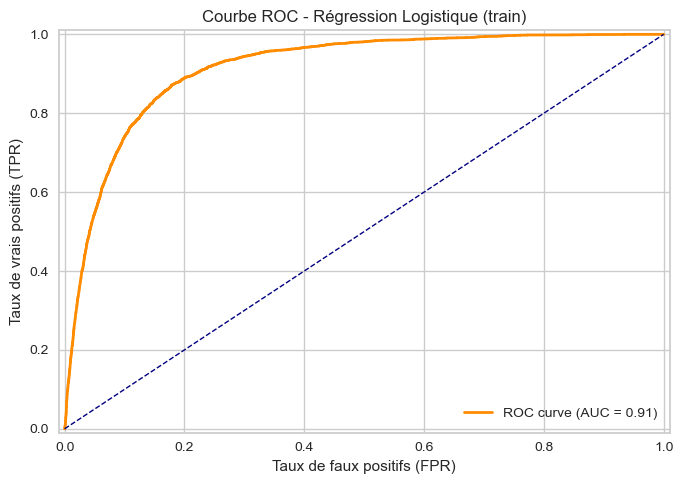

In [144]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Régression Logistique (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interprètation :** La courbe ROC mesure en général la capacité du modèle à discriminer entre les classes (yes/no). Ici on constate un score de 91% on peut donc conclure que le modèle a excellente capacité de discrimination : il classe bien les clients susceptibles de dire « yes » et ceux qui diront « no ».

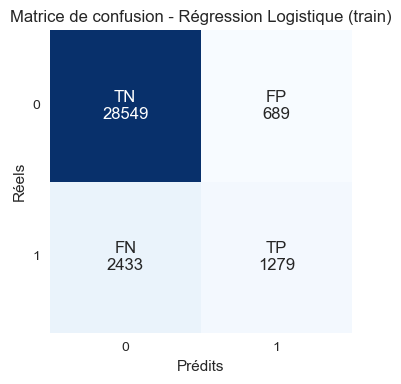

In [145]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_train, y_pred_train)

# Définition des étiquettes : TP, FP, FN, TN
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Création de l’annotation personnalisée
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}"

# Affichage avec seaborn
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Régression Logistique (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

**Interprètation**

## **DECISION TREE (DT)**

In [146]:
# Entrainement du modèle - Arbre de Décision
classifier2 = DecisionTreeClassifier(
    criterion='gini',     # ou 'entropy' si tu veux
    max_depth=None,       # tu peux limiter la profondeur pour éviter l'overfitting
    random_state=0
)

classifier2.fit(X_train, y_train)


DecisionTreeClassifier(random_state=0)

**Interprètation**

In [147]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_tree = classifier2.predict(X_train)
y_prob_train_tree = classifier2.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_tree = precision_score(y_train, y_pred_train_tree)
recall_tree = recall_score(y_train, y_pred_train_tree)
accuracy_tree = accuracy_score(y_train, y_pred_train_tree)
error_rate_tree = 1 - accuracy_tree
f1_score_tree = f1_score(y_train, y_pred_train_tree)
ck_tree = cohen_kappa_score(y_train, y_pred_train_tree)
mc_tree = matthews_corrcoef(y_train, y_pred_train_tree)
auc_tree = roc_auc_score(y_train, y_prob_train_tree)

# 3. Affichage des métriques
print("✅ Évaluation du modèle Arbre de Décision sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_tree:.3f}")
print(f"Recall           : {recall_tree:.3f}")
print(f"Accuracy         : {accuracy_tree:.3f}")
print(f"Error Rate       : {error_rate_tree:.3f}")
print(f"F1 Score         : {f1_score_tree:.3f}")
print(f"Cohen's Kappa    : {ck_tree:.3f}")
print(f"Matthews Corrcoef: {mc_tree:.3f}")
print(f"AUC              : {auc_tree:.3f}")


### === TEST === ###
y_pred_test_tree = classifier2.predict(X_test)
y_prob_test_tree = classifier2.predict_proba(X_test)[:, 1]

precision_tree_test = precision_score(y_test, y_pred_test_tree)
recall_tree_test = recall_score(y_test, y_pred_test_tree)
accuracy_tree_test = accuracy_score(y_test, y_pred_test_tree)
error_rate_tree_test = 1 - accuracy_tree_test
f1_score_tree_test = f1_score(y_test, y_pred_test_tree)
ck_tree_test = cohen_kappa_score(y_test, y_pred_test_tree)
mc_tree_test = matthews_corrcoef(y_test, y_pred_test_tree)
auc_tree_test = roc_auc_score(y_test, y_prob_test_tree)

print("📊 Évaluation du modèle Arbre de Décision (TEST) :\n")
print(f"Precision        : {precision_tree_test:.3f}")
print(f"Recall           : {recall_tree_test:.3f}")
print(f"Accuracy         : {accuracy_tree_test:.3f}")
print(f"Error Rate       : {error_rate_tree_test:.3f}")
print(f"F1 Score         : {f1_score_tree_test:.3f}")
print(f"Cohen's Kappa    : {ck_tree_test:.3f}")
print(f"Matthews Corrcoef: {mc_tree_test:.3f}")
print(f"AUC              : {auc_tree_test:.3f}")

✅ Évaluation du modèle Arbre de Décision sur le jeu d'entraînement :

Precision        : 1.000
Recall           : 1.000
Accuracy         : 1.000
Error Rate       : 0.000
F1 Score         : 1.000
Cohen's Kappa    : 1.000
Matthews Corrcoef: 1.000
AUC              : 1.000
📊 Évaluation du modèle Arbre de Décision (TEST) :

Precision        : 0.457
Recall           : 0.492
Accuracy         : 0.877
Error Rate       : 0.123
F1 Score         : 0.474
Cohen's Kappa    : 0.404
Matthews Corrcoef: 0.405
AUC              : 0.709


**Interprètation:** Le modèle prédit parfaitement toutes les observations du jeu d'entraînement : il détecte tous les cas positifs et négatifs sans erreur. Cela signifie qu’il a mémorisé les données d'entraînement — aucune erreur, ni faux positifs, ni faux négatifs se traduisant par des métriques idéales (1.000) sur toutes les dimensions de performance.

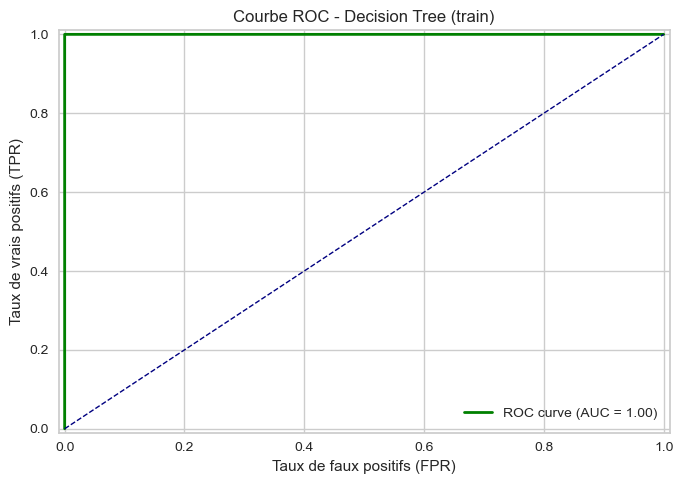

In [148]:
# Calcul pour la courbe ROC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_train, y_prob_train_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Decision Tree (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interprètation :** L’aire sous la courbe (AUC) est de 1.00, soit le score parfait. Cela signifie que le modèle classe parfaitement tous les clients intéressés (yes) au-dessus de tous les clients non intéressés (no). Il ne fait aucune confusion entre les deux classes, peu importe le seuil de décision C'est pour cela que nous observons  que La courbe ROC, épouse l’angle supérieur gauche du graphique (recall = 1, FPR = 0), ce qui est l’idéal.

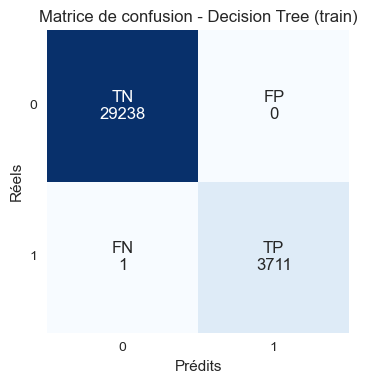

In [149]:
# Calcul de la matrice de confusion
cm_tree = confusion_matrix(y_train, y_pred_train_tree)

# Définition des étiquettes : TN, FP, FN, TP
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Création de l’annotation personnalisée
annot = np.empty_like(cm_tree).astype(str)
for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_tree[i, j]}"

# Affichage
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=annot, fmt='', cmap='Blues', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Decision Tree (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


**Interprètation :** **True Negatives (29 238)** : Le modèle a correctement identifié la grande majorité des clients qui n’étaient pas intéressés afin d'éviter les efforts inutiles sur des clients non réceptifs.
**False Positives (0)** : Aucun client non intéressé n’a été ciblé à tort ce qui témoigne d'une précision commerciale quasi parfaite
**True Positives (3 711)** : Le modèle a correctement détecté presque tous les clients intéressés par un dépôt à terme;  on pourrait donner une note de 10 à la performance marketing.
**False Negatives (1)** : Un seul client intéressé a été manqué; On peut donc conclure que Le modèle réussit remarquablement bien à minimiser le coût des campagnes (aucun faux positif → pas d’envoi inutile), maximiser le taux de souscription (presque tous les vrais clients intéressés sont détectés), puis d'optimiser la conversion en s’adressant aux bons profils uniquement.

## **DECISION TREE AVEC MODIFICATION DES ARGUMENTS DANS LE MODELE** 

In [150]:
# Entrainement du modèle - Arbre de Décision régularisé
classifier2 = DecisionTreeClassifier(
    criterion='gini',       # ou 'entropy'
    max_depth=6,            # limite la profondeur de l’arbre
    min_samples_leaf=10,    # nombre minimum d’échantillons par feuille
    random_state=0
)

classifier2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=0)

In [151]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_tree = classifier2.predict(X_train)
y_prob_train_tree = classifier2.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_tree = precision_score(y_train, y_pred_train_tree)
recall_tree = recall_score(y_train, y_pred_train_tree)
accuracy_tree = accuracy_score(y_train, y_pred_train_tree)
error_rate_tree = 1 - accuracy_tree
f1_score_tree = f1_score(y_train, y_pred_train_tree)
ck_tree = cohen_kappa_score(y_train, y_pred_train_tree)
mc_tree = matthews_corrcoef(y_train, y_pred_train_tree)
auc_tree = roc_auc_score(y_train, y_prob_train_tree)

# 3. Affichage des métriques
print("✅ Évaluation du modèle Arbre de Décision sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_tree:.3f}")
print(f"Recall           : {recall_tree:.3f}")
print(f"Accuracy         : {accuracy_tree:.3f}")
print(f"Error Rate       : {error_rate_tree:.3f}")
print(f"F1 Score         : {f1_score_tree:.3f}")
print(f"Cohen's Kappa    : {ck_tree:.3f}")
print(f"Matthews Corrcoef: {mc_tree:.3f}")
print(f"AUC              : {auc_tree:.3f}")


### === TEST === ###
y_pred_test_tree = classifier2.predict(X_test)
y_prob_test_tree = classifier2.predict_proba(X_test)[:, 1]

precision_tree_test = precision_score(y_test, y_pred_test_tree)
recall_tree_test = recall_score(y_test, y_pred_test_tree)
accuracy_tree_test = accuracy_score(y_test, y_pred_test_tree)
error_rate_tree_test = 1 - accuracy_tree_test
f1_score_tree_test = f1_score(y_test, y_pred_test_tree)
ck_tree_test = cohen_kappa_score(y_test, y_pred_test_tree)
mc_tree_test = matthews_corrcoef(y_test, y_pred_test_tree)
auc_tree_test = roc_auc_score(y_test, y_prob_test_tree)

print("📊 Évaluation du modèle Arbre de Décision (TEST) :\n")
print(f"Precision        : {precision_tree_test:.3f}")
print(f"Recall           : {recall_tree_test:.3f}")
print(f"Accuracy         : {accuracy_tree_test:.3f}")
print(f"Error Rate       : {error_rate_tree_test:.3f}")
print(f"F1 Score         : {f1_score_tree_test:.3f}")
print(f"Cohen's Kappa    : {ck_tree_test:.3f}")
print(f"Matthews Corrcoef: {mc_tree_test:.3f}")
print(f"AUC              : {auc_tree_test:.3f}")

✅ Évaluation du modèle Arbre de Décision sur le jeu d'entraînement :

Precision        : 0.694
Recall           : 0.401
Accuracy         : 0.913
Error Rate       : 0.087
F1 Score         : 0.509
Cohen's Kappa    : 0.464
Matthews Corrcoef: 0.485
AUC              : 0.874
📊 Évaluation du modèle Arbre de Décision (TEST) :

Precision        : 0.692
Recall           : 0.400
Accuracy         : 0.912
Error Rate       : 0.088
F1 Score         : 0.507
Cohen's Kappa    : 0.462
Matthews Corrcoef: 0.484
AUC              : 0.866


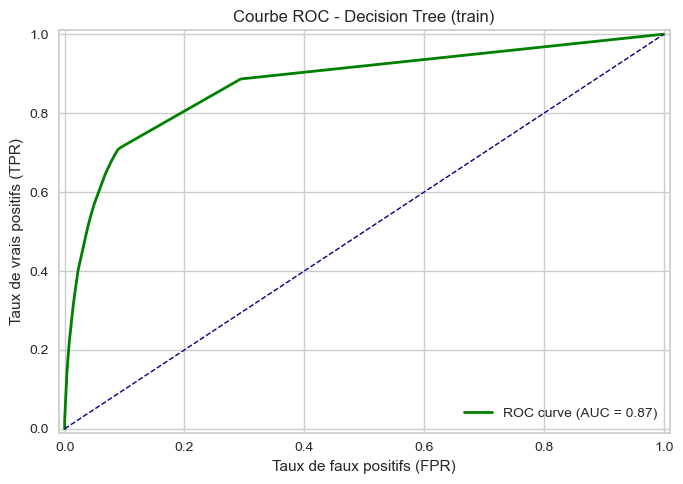

In [152]:
# Calcul pour la courbe ROC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_train, y_prob_train_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Decision Tree (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

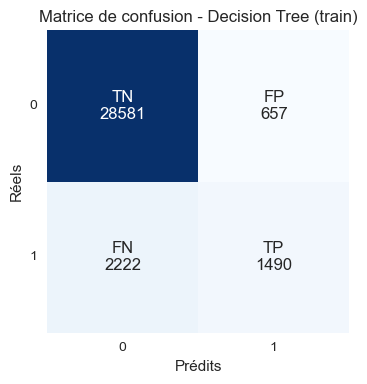

In [153]:
# Calcul de la matrice de confusion
cm_tree = confusion_matrix(y_train, y_pred_train_tree)

# Définition des étiquettes : TN, FP, FN, TP
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Création de l’annotation personnalisée
annot = np.empty_like(cm_tree).astype(str)
for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_tree[i, j]}"

# Affichage
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=annot, fmt='', cmap='Blues', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Decision Tree (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


## **RANDOM FOREST**

In [154]:
# Entrainement du modèle
classifier3 = RandomForestClassifier(
    n_estimators=100,    # Nombre d'arbres
    criterion='gini',    # Critère de séparation
    max_depth=None,      # Profondeur des arbres (None = pas de limite)
    random_state=0
)
classifier3.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

**Interprètation**

In [155]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_rf = classifier3.predict(X_train)
y_prob_train_rf = classifier3.predict_proba(X_train)[:, 1]

precision_rf_train = precision_score(y_train, y_pred_train_rf)
recall_rf_train = recall_score(y_train, y_pred_train_rf)
accuracy_rf_train = accuracy_score(y_train, y_pred_train_rf)
error_rate_rf_train = 1 - accuracy_rf_train
f1_score_rf_train = f1_score(y_train, y_pred_train_rf)
ck_rf_train = cohen_kappa_score(y_train, y_pred_train_rf)
mc_rf_train = matthews_corrcoef(y_train, y_pred_train_rf)
auc_rf_train = roc_auc_score(y_train, y_prob_train_rf)

print("✅ Évaluation du modèle Random Forest (TRAIN) :\n")
print(f"Precision        : {precision_rf_train:.3f}")
print(f"Recall           : {recall_rf_train:.3f}")
print(f"Accuracy         : {accuracy_rf_train:.3f}")
print(f"Error Rate       : {error_rate_rf_train:.3f}")
print(f"F1 Score         : {f1_score_rf_train:.3f}")
print(f"Cohen's Kappa    : {ck_rf_train:.3f}")
print(f"Matthews Corrcoef: {mc_rf_train:.3f}")
print(f"AUC              : {auc_rf_train:.3f}")
print("-" * 50)

### === TEST === ###
y_pred_test_rf = classifier3.predict(X_test)
y_prob_test_rf = classifier3.predict_proba(X_test)[:, 1]

precision_rf_test = precision_score(y_test, y_pred_test_rf)
recall_rf_test = recall_score(y_test, y_pred_test_rf)
accuracy_rf_test = accuracy_score(y_test, y_pred_test_rf)
error_rate_rf_test = 1 - accuracy_rf_test
f1_score_rf_test = f1_score(y_test, y_pred_test_rf)
ck_rf_test = cohen_kappa_score(y_test, y_pred_test_rf)
mc_rf_test = matthews_corrcoef(y_test, y_pred_test_rf)
auc_rf_test = roc_auc_score(y_test, y_prob_test_rf)

print("📊 Évaluation du modèle Random Forest (TEST) :\n")
print(f"Precision        : {precision_rf_test:.3f}")
print(f"Recall           : {recall_rf_test:.3f}")
print(f"Accuracy         : {accuracy_rf_test:.3f}")
print(f"Error Rate       : {error_rate_rf_test:.3f}")
print(f"F1 Score         : {f1_score_rf_test:.3f}")
print(f"Cohen's Kappa    : {ck_rf_test:.3f}")
print(f"Matthews Corrcoef: {mc_rf_test:.3f}")
print(f"AUC              : {auc_rf_test:.3f}")



✅ Évaluation du modèle Random Forest (TRAIN) :

Precision        : 1.000
Recall           : 1.000
Accuracy         : 1.000
Error Rate       : 0.000
F1 Score         : 1.000
Cohen's Kappa    : 1.000
Matthews Corrcoef: 1.000
AUC              : 1.000
--------------------------------------------------
📊 Évaluation du modèle Random Forest (TEST) :

Precision        : 0.680
Recall           : 0.415
Accuracy         : 0.912
Error Rate       : 0.088
F1 Score         : 0.515
Cohen's Kappa    : 0.470
Matthews Corrcoef: 0.488
AUC              : 0.926


**Interprètation**

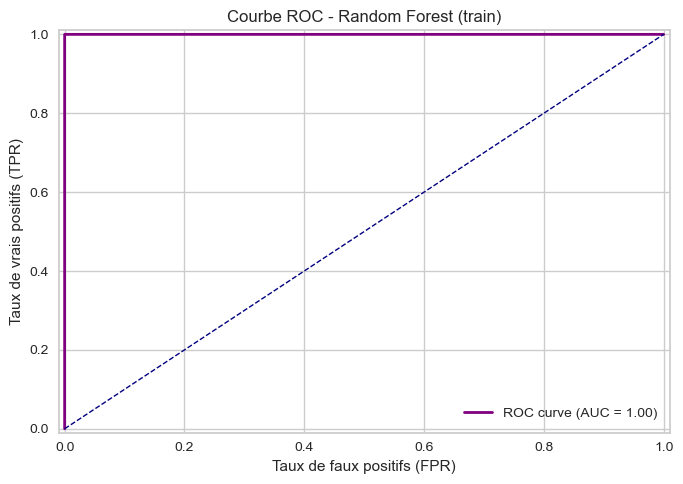

In [156]:
# Calcul pour la courbe ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_train, y_prob_train_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Random Forest (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interprètation**

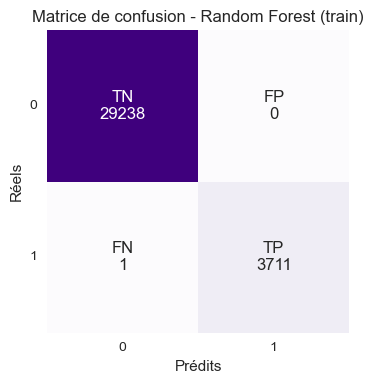

In [157]:
# Calcul de la matrice de confusion
cm_rf = confusion_matrix(y_train, y_pred_train_rf)

# Définir les étiquettes
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Annotation personnalisée
annot = np.empty_like(cm_rf).astype(str)
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_rf[i, j]}"

# Affichage avec une nouvelle couleur (par exemple "Purples" pour Random Forest)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=annot, fmt='', cmap='Purples', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Random Forest (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

**Interprètation**

## **RANDOM FOREST AVEC MODIFICATION DES ARGUMENTS**

In [158]:
# Entrainement du modèle - Random Forest régularisé
classifier3 = RandomForestClassifier(
    n_estimators=100,         # Nombre d'arbres
    criterion='gini',         # ou 'entropy'
    max_depth=10,             # Limite la profondeur de chaque arbre
    min_samples_leaf=10,      # Minimum d’échantillons dans une feuille
    max_features='sqrt',      # Nombre de features à considérer à chaque split (sqrt = classique)
    random_state=0,
    n_jobs=-1                 # Utilise tous les cœurs pour aller plus vite
)

classifier3.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, n_jobs=-1,
                       random_state=0)

In [159]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_rf = classifier3.predict(X_train)
y_prob_train_rf = classifier3.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_rf = precision_score(y_train, y_pred_train_rf)
recall_rf = recall_score(y_train, y_pred_train_rf)
accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
error_rate_rf = 1 - accuracy_rf
f1_score_rf = f1_score(y_train, y_pred_train_rf)
ck_rf = cohen_kappa_score(y_train, y_pred_train_rf)
mc_rf = matthews_corrcoef(y_train, y_pred_train_rf)
auc_rf = roc_auc_score(y_train, y_prob_train_rf)

# 3. Affichage des métriques
print("✅ Évaluation du modèle Random Forest sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_rf:.3f}")
print(f"Recall           : {recall_rf:.3f}")
print(f"Accuracy         : {accuracy_rf:.3f}")
print(f"Error Rate       : {error_rate_rf:.3f}")
print(f"F1 Score         : {f1_score_rf:.3f}")
print(f"Cohen's Kappa    : {ck_rf:.3f}")
print(f"Matthews Corrcoef: {mc_rf:.3f}")
print(f"AUC              : {auc_rf:.3f}")



### === TEST === ###
y_pred_test_rf = classifier3.predict(X_test)
y_prob_test_rf = classifier3.predict_proba(X_test)[:, 1]

precision_rf_test = precision_score(y_test, y_pred_test_rf)
recall_rf_test = recall_score(y_test, y_pred_test_rf)
accuracy_rf_test = accuracy_score(y_test, y_pred_test_rf)
error_rate_rf_test = 1 - accuracy_rf_test
f1_score_rf_test = f1_score(y_test, y_pred_test_rf)
ck_rf_test = cohen_kappa_score(y_test, y_pred_test_rf)
mc_rf_test = matthews_corrcoef(y_test, y_pred_test_rf)
auc_rf_test = roc_auc_score(y_test, y_prob_test_rf)

print("📊 Évaluation du modèle Random Forest (TEST) :\n")
print(f"Precision        : {precision_rf_test:.3f}")
print(f"Recall           : {recall_rf_test:.3f}")
print(f"Accuracy         : {accuracy_rf_test:.3f}")
print(f"Error Rate       : {error_rate_rf_test:.3f}")
print(f"F1 Score         : {f1_score_rf_test:.3f}")
print(f"Cohen's Kappa    : {ck_rf_test:.3f}")
print(f"Matthews Corrcoef: {mc_rf_test:.3f}")
print(f"AUC              : {auc_rf_test:.3f}")


✅ Évaluation du modèle Random Forest sur le jeu d'entraînement :

Precision        : 0.784
Recall           : 0.204
Accuracy         : 0.904
Error Rate       : 0.096
F1 Score         : 0.323
Cohen's Kappa    : 0.290
Matthews Corrcoef: 0.369
AUC              : 0.930
📊 Évaluation du modèle Random Forest (TEST) :

Precision        : 0.797
Recall           : 0.191
Accuracy         : 0.903
Error Rate       : 0.097
F1 Score         : 0.308
Cohen's Kappa    : 0.276
Matthews Corrcoef: 0.360
AUC              : 0.922


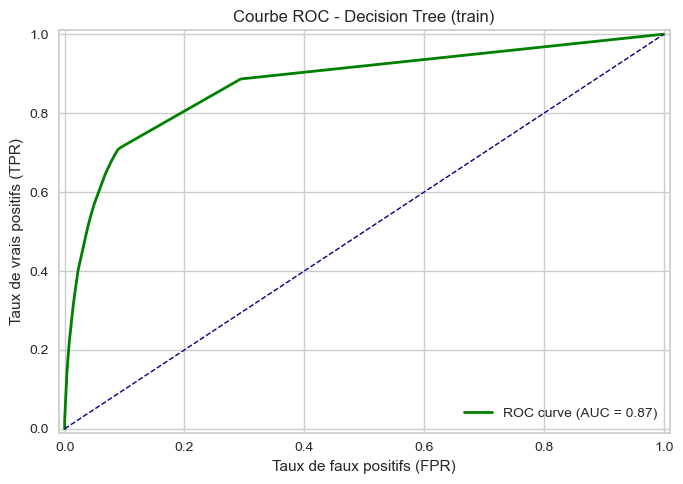

In [160]:
# Calcul pour la courbe ROC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_train, y_prob_train_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Decision Tree (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

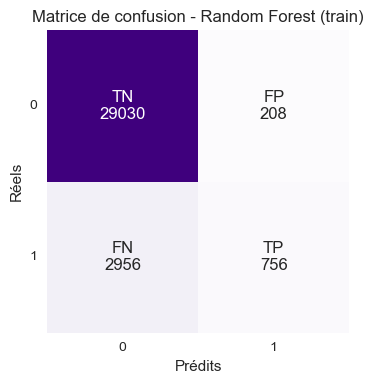

In [161]:
# Calcul de la matrice de confusion
cm_rf = confusion_matrix(y_train, y_pred_train_rf)

# Définir les étiquettes
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Annotation personnalisée
annot = np.empty_like(cm_rf).astype(str)
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_rf[i, j]}"

# Affichage avec une nouvelle couleur (par exemple "Purples" pour Random Forest)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=annot, fmt='', cmap='Purples', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Random Forest (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

## **XGBoost**

In [162]:
# Entrainement du modèle XGBoost
classifier4 = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',  # Important pour éviter un warning
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    random_state=0
)
classifier4.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [163]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_xgb = classifier4.predict(X_train)
y_prob_train_xgb = classifier4.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_xgb = precision_score(y_train, y_pred_train_xgb)
recall_xgb = recall_score(y_train, y_pred_train_xgb)
accuracy_xgb = accuracy_score(y_train, y_pred_train_xgb)
error_rate_xgb = 1 - accuracy_xgb
f1_score_xgb = f1_score(y_train, y_pred_train_xgb)
ck_xgb = cohen_kappa_score(y_train, y_pred_train_xgb)
mc_xgb = matthews_corrcoef(y_train, y_pred_train_xgb)
auc_xgb = roc_auc_score(y_train, y_prob_train_xgb)

# 3. Affichage des métriques
print("✅ Évaluation du modèle XGBoost sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_xgb:.3f}")
print(f"Recall           : {recall_xgb:.3f}")
print(f"Accuracy         : {accuracy_xgb:.3f}")
print(f"Error Rate       : {error_rate_xgb:.3f}")
print(f"F1 Score         : {f1_score_xgb:.3f}")
print(f"Cohen's Kappa    : {ck_xgb:.3f}")
print(f"Matthews Corrcoef: {mc_xgb:.3f}")
print(f"AUC              : {auc_xgb:.3f}")


✅ Évaluation du modèle XGBoost sur le jeu d'entraînement :

Precision        : 0.679
Recall           : 0.423
Accuracy         : 0.913
Error Rate       : 0.087
F1 Score         : 0.522
Cohen's Kappa    : 0.476
Matthews Corrcoef: 0.492
AUC              : 0.931


**Interprètation**

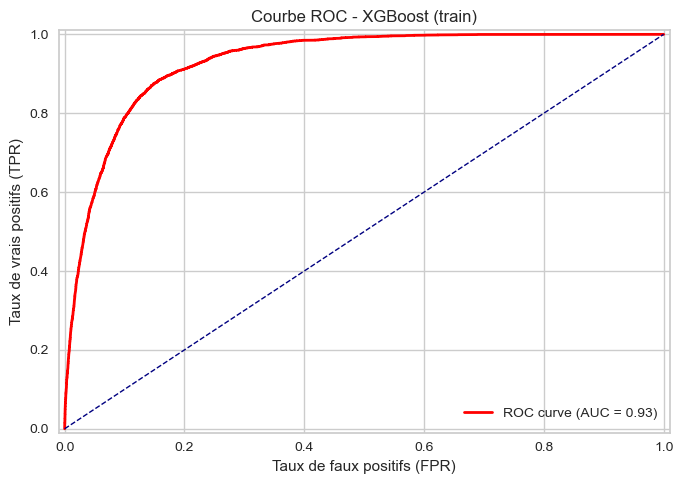

In [164]:
# Calcul pour la courbe ROC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_train, y_prob_train_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - XGBoost (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interprètation**

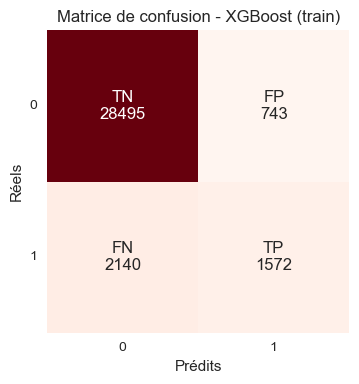

In [165]:
# Calcul de la matrice de confusion
cm_xgb = confusion_matrix(y_train, y_pred_train_xgb)

# Définir les étiquettes
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Annotation personnalisée
annot = np.empty_like(cm_xgb).astype(str)
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_xgb[i, j]}"

# Affichage avec une couleur différente (par exemple "Reds" pour XGBoost)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=annot, fmt='', cmap='Reds', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - XGBoost (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


**Interprètation**

## **KNN (K-Nearest Neighbors)**

In [166]:
# Entrainement du modèle KNN
classifier5 = KNeighborsClassifier(
    n_neighbors=5,    # Nombre de voisins
    metric='minkowski',  # Distance utilisée
    p=2                # p=2 => distance euclidienne
)
classifier5.fit(X_train, y_train)


KNeighborsClassifier()

In [167]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_knn = classifier5.predict(X_train)
y_prob_train_knn = classifier5.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_knn = precision_score(y_train, y_pred_train_knn)
recall_knn = recall_score(y_train, y_pred_train_knn)
accuracy_knn = accuracy_score(y_train, y_pred_train_knn)
error_rate_knn = 1 - accuracy_knn
f1_score_knn = f1_score(y_train, y_pred_train_knn)
ck_knn = cohen_kappa_score(y_train, y_pred_train_knn)
mc_knn = matthews_corrcoef(y_train, y_pred_train_knn)
auc_knn = roc_auc_score(y_train, y_prob_train_knn)

# 3. Affichage des métriques
print("✅ Évaluation du modèle KNN sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_knn:.3f}")
print(f"Recall           : {recall_knn:.3f}")
print(f"Accuracy         : {accuracy_knn:.3f}")
print(f"Error Rate       : {error_rate_knn:.3f}")
print(f"F1 Score         : {f1_score_knn:.3f}")
print(f"Cohen's Kappa    : {ck_knn:.3f}")
print(f"Matthews Corrcoef: {mc_knn:.3f}")
print(f"AUC              : {auc_knn:.3f}")


✅ Évaluation du modèle KNN sur le jeu d'entraînement :

Precision        : 0.752
Recall           : 0.496
Accuracy         : 0.925
Error Rate       : 0.075
F1 Score         : 0.598
Cohen's Kappa    : 0.558
Matthews Corrcoef: 0.573
AUC              : 0.960


**Interprètation**

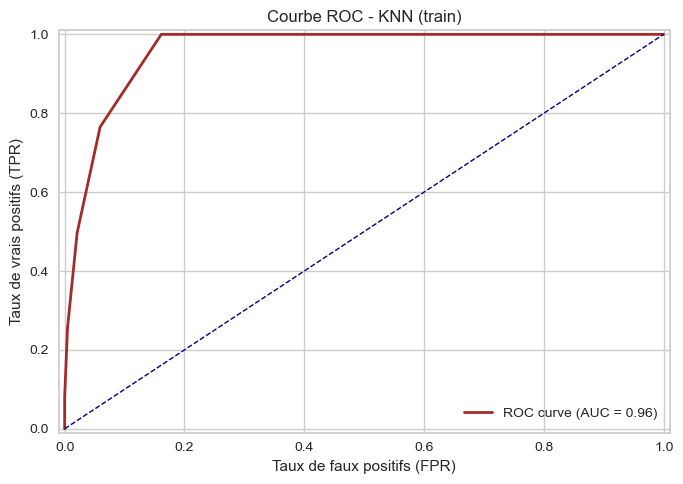

In [168]:
# Calcul pour la courbe ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_train, y_prob_train_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, color='brown', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - KNN (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


**Interprètation**

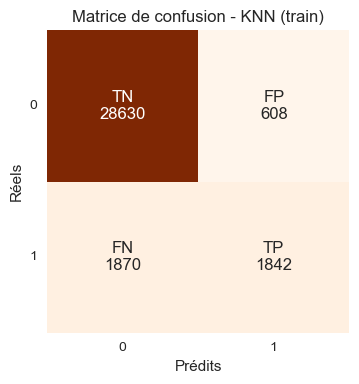

In [169]:
# Calcul de la matrice de confusion
cm_knn = confusion_matrix(y_train, y_pred_train_knn)

# Définir les étiquettes
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Annotation personnalisée
annot = np.empty_like(cm_knn).astype(str)
for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_knn[i, j]}"

# Affichage avec une nouvelle couleur (par exemple "Oranges" pour KNN)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=annot, fmt='', cmap='Oranges', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - KNN (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()


**Interprètation**

## **Naives BAYES**

In [170]:
# Entrainement du modèle Naive Bayes avec arguments
classifier6 = GaussianNB(
    priors=None,        # Laisser sklearn estimer à partir des données
    var_smoothing=1e-9  # Smoothing numérique pour stabilité
)
classifier6.fit(X_train, y_train)


GaussianNB()

In [171]:
# 1. Prédictions sur le jeu d'entraînement
y_pred_train_nb = classifier6.predict(X_train)
y_prob_train_nb = classifier6.predict_proba(X_train)[:, 1]

# 2. Calcul des métriques
precision_nb = precision_score(y_train, y_pred_train_nb)
recall_nb = recall_score(y_train, y_pred_train_nb)
accuracy_nb = accuracy_score(y_train, y_pred_train_nb)
error_rate_nb = 1 - accuracy_nb
f1_score_nb = f1_score(y_train, y_pred_train_nb)
ck_nb = cohen_kappa_score(y_train, y_pred_train_nb)
mc_nb = matthews_corrcoef(y_train, y_pred_train_nb)
auc_nb = roc_auc_score(y_train, y_prob_train_nb)

# 3. Affichage des métriques
print("✅ Évaluation du modèle Naive Bayes sur le jeu d'entraînement :\n")
print(f"Precision        : {precision_nb:.3f}")
print(f"Recall           : {recall_nb:.3f}")
print(f"Accuracy         : {accuracy_nb:.3f}")
print(f"Error Rate       : {error_rate_nb:.3f}")
print(f"F1 Score         : {f1_score_nb:.3f}")
print(f"Cohen's Kappa    : {ck_nb:.3f}")
print(f"Matthews Corrcoef: {mc_nb:.3f}")
print(f"AUC              : {auc_nb:.3f}")

✅ Évaluation du modèle Naive Bayes sur le jeu d'entraînement :

Precision        : 0.367
Recall           : 0.565
Accuracy         : 0.841
Error Rate       : 0.159
F1 Score         : 0.445
Cohen's Kappa    : 0.357
Matthews Corrcoef: 0.368
AUC              : 0.825


**Interprètation**

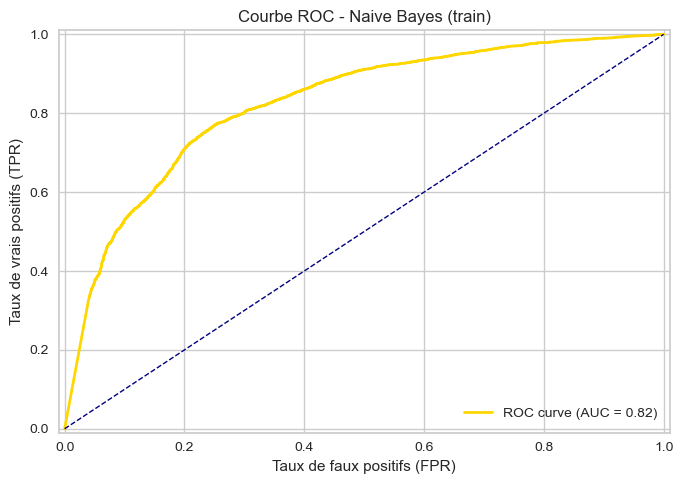

In [172]:
# Calcul pour la courbe ROC
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_train, y_prob_train_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, color='gold', lw=2, label=f'ROC curve (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Naive Bayes (train)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Interprètation**

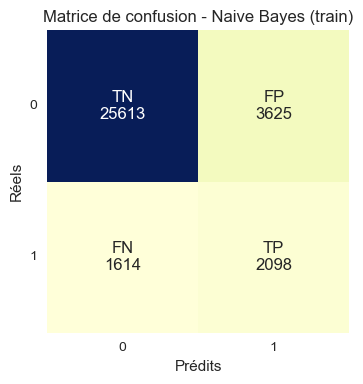

In [173]:
# Calcul de la matrice de confusion
cm_nb = confusion_matrix(y_train, y_pred_train_nb)

# Définir les étiquettes
labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])

# Annotation personnalisée
annot = np.empty_like(cm_nb).astype(str)
for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_nb[i, j]}"

# Affichage avec une nouvelle couleur (par exemple "YlGnBu" pour Naive Bayes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=annot, fmt='', cmap='YlGnBu', cbar=False, square=True)
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion - Naive Bayes (train)')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.yticks([0.5, 1.5], ['0', '1'], rotation=0)
plt.tight_layout()
plt.show()

**Interprètation**

### **METRICS OF THE MODELS**

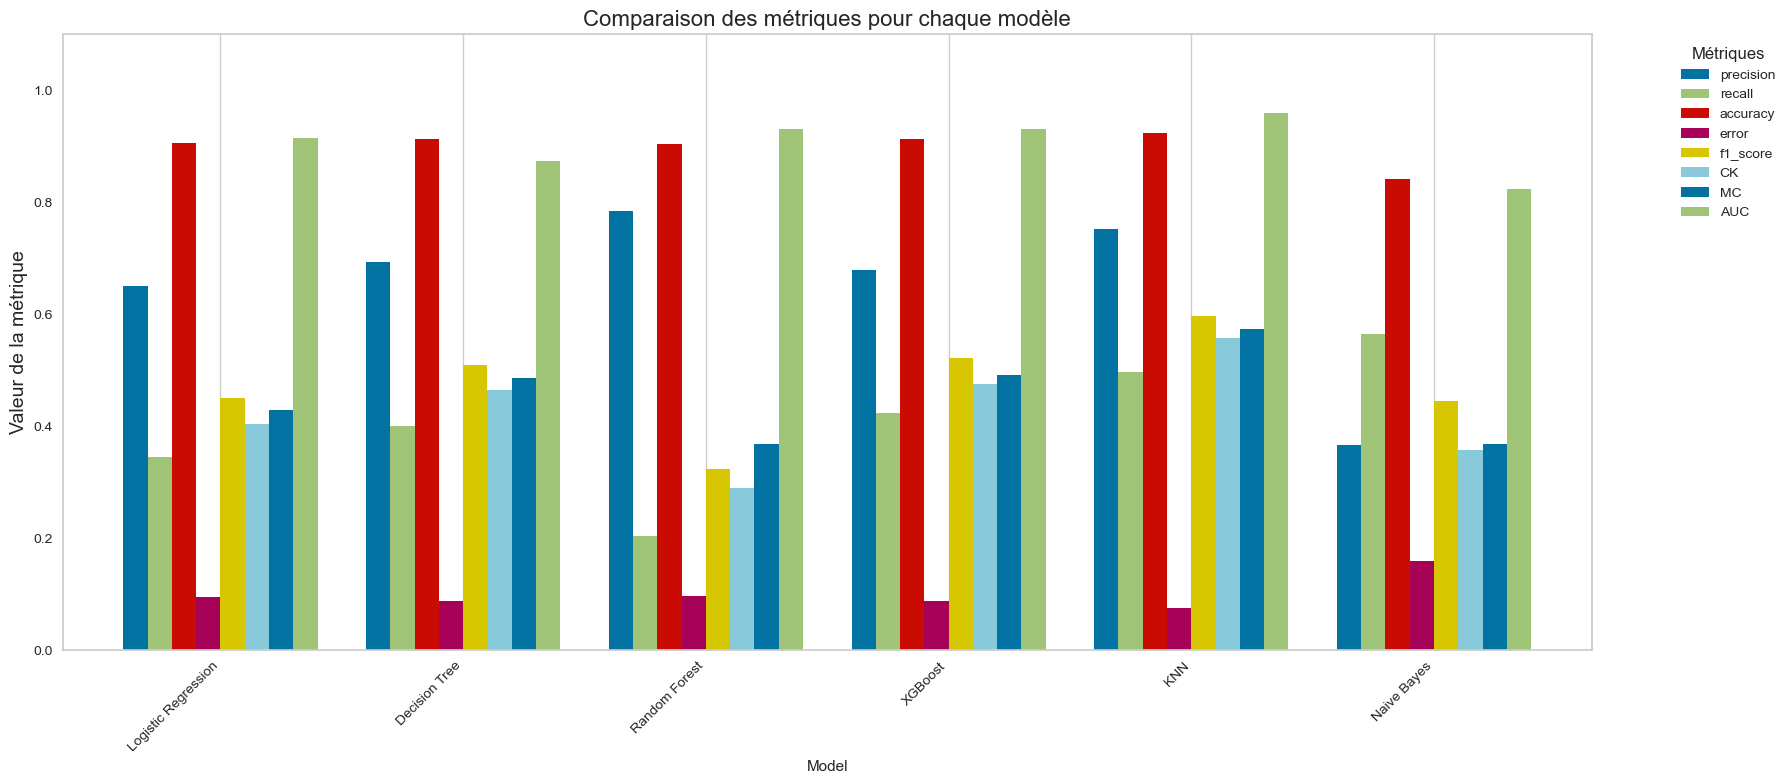

In [174]:
# 1. Regrouper toutes les métriques dans un DataFrame
metrics_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'KNN', 'Naive Bayes'
    ],
    'precision': [
        precision, precision_tree, precision_rf, precision_xgb, precision_knn, precision_nb
    ],
    'recall': [
        recall, recall_tree, recall_rf, recall_xgb, recall_knn, recall_nb
    ],
    'accuracy': [
        Accuracy_Rate, accuracy_tree, accuracy_rf, accuracy_xgb, accuracy_knn, accuracy_nb
    ],
    'error': [
        1-Accuracy_Rate, 1-accuracy_tree, 1-accuracy_rf, 1-accuracy_xgb, 1-accuracy_knn, 1-accuracy_nb
    ],
    'f1_score': [
        F1_score_logreg, f1_score_tree, f1_score_rf, f1_score_xgb, f1_score_knn, f1_score_nb
    ],
    'CK': [
        CK, ck_tree, ck_rf, ck_xgb, ck_knn, ck_nb
    ],
    'MC': [
        MC, mc_tree, mc_rf, mc_xgb, mc_knn, mc_nb
    ],
    'AUC': [
        AUC, auc_tree, auc_rf, auc_xgb, auc_knn, auc_nb
    ]
})

# 2. Plot Grouped Bar Chart
metrics_comparison.set_index('Model', inplace=True)

# Définir la taille
fig, ax = plt.subplots(figsize=(18, 8))

# Tracer les barres groupées
metrics_comparison.plot(kind='bar', ax=ax, width=0.8)

# Paramètres de style
plt.title('Comparaison des métriques pour chaque modèle', fontsize=16)
plt.ylabel('Valeur de la métrique', fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Afficher
plt.show()


**Interprètation :** 

### **AUC OF THE MODELS**

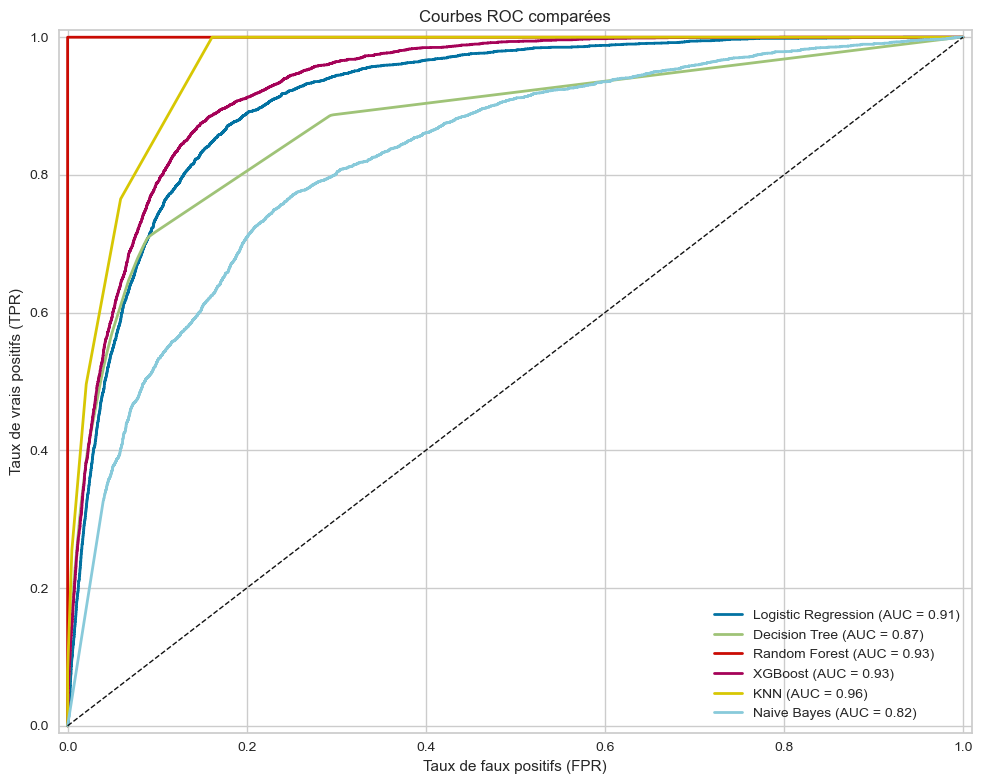

In [175]:
plt.figure(figsize=(10, 8))

# Tracer les courbes ROC pour chaque modèle
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {AUC:.2f})', lw=2)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', lw=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.2f})', lw=2)

# Ligne de base
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Paramètres
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC comparées')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

plt.show()


**Interprètation**

### **MATRIX CONFUSION OF THE MODELS**

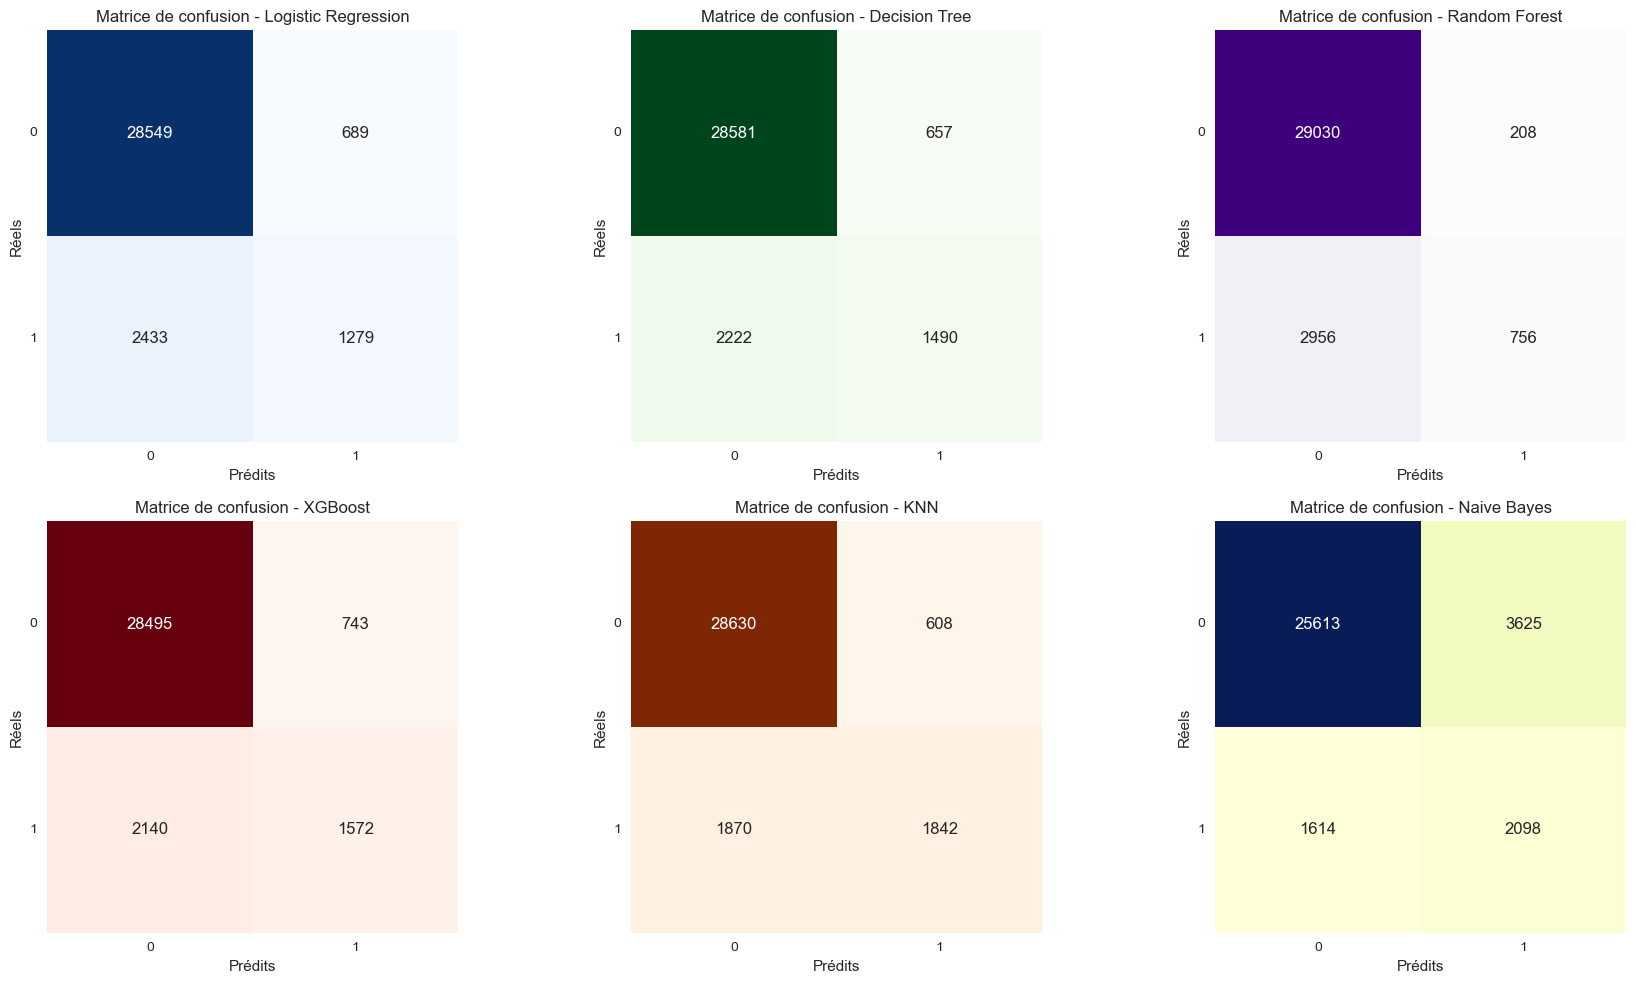

In [176]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Dictionnaire pour tout organiser
conf_matrices = {
    'Logistic Regression': cm,
    'Decision Tree': cm_tree,
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb,
    'KNN': cm_knn,
    'Naive Bayes': cm_nb
}

# Couleurs différentes pour chaque modèle
colors = ['Blues', 'Greens', 'Purples', 'Reds', 'Oranges', 'YlGnBu']

# Boucle sur chaque matrice
for idx, (model_name, matrix) in enumerate(conf_matrices.items()):
    sns.heatmap(
        matrix, annot=True, fmt='d', cmap=colors[idx],
        cbar=False, ax=axes[idx], square=True
    )
    axes[idx].set_title(f'Matrice de confusion - {model_name}')
    axes[idx].set_xlabel('Prédits')
    axes[idx].set_ylabel('Réels')
    axes[idx].set_xticks([0.5, 1.5])
    axes[idx].set_xticklabels(['0', '1'])
    axes[idx].set_yticks([0.5, 1.5])
    axes[idx].set_yticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()


**Interprètation**

# **V- Présentation des résultats et recommandations**

In [178]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Appliquer permutation importance sur le modèle KNN déjà entraîné
result = permutation_importance(classifier5, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)

# Créer un DataFrame lisible
perm_df = pd.DataFrame({
    'Variable': X_test.columns,
    'Importance moyenne': result.importances_mean,
    'Écart-type': result.importances_std
}).sort_values(by='Importance moyenne', ascending=False)

# Affichage
print(perm_df.head(10))  # top 10


             Variable  Importance moyenne  Écart-type
1            duration            0.028077    0.001634
3               pdays            0.019616    0.000986
30  contact_telephone            0.002756    0.000971
33          month_jul            0.001469    0.000826
4            previous            0.001275    0.000729
31          month_aug            0.001275    0.000404
37          month_nov            0.000850    0.000399
40    day_of_week_mon            0.000546    0.000901
39          month_sep            0.000473    0.000148
35          month_mar            0.000340    0.000223


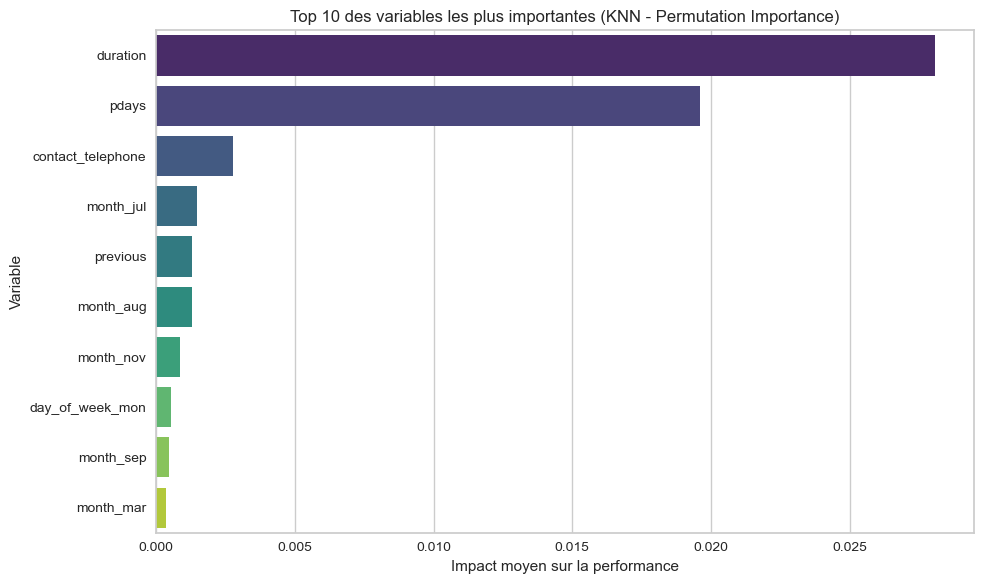

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import pandas as pd

# 1. Calcul de l'importance des variables par permutation
result = permutation_importance(classifier5, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)

# 2. Organiser les résultats dans un DataFrame
perm_df = pd.DataFrame({
    'Variable': X_test.columns,
    'Importance moyenne': result.importances_mean,
    'Écart-type': result.importances_std
}).sort_values(by='Importance moyenne', ascending=False)

# 3. Plot des 10 variables les plus importantes
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_df.head(10),
    y='Variable',
    x='Importance moyenne',
    palette='viridis',
    orient='h'
)
plt.title("Top 10 des variables les plus importantes (KNN - Permutation Importance)")
plt.xlabel("Impact moyen sur la performance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


**Interprètation**

# **V- QUESTIONS PROFESSIONNELLES ORIENTEES PRISE DE DECISION**

## **1. Quels segments de clients montrent la plus grande propension à souscrire à l’offre, et quels types d’actions marketing recommanderiez-vous pour les cibler efficacement** ?

Basé sur l'importance des variables de mon modèle KNN et leur impact pour la Segmentation de clients: 

a)- Clients ayant une longue durée d'appel	La durée est le facteur numéro 1 → plus le client reste au téléphone, plus il est intéressé.

c)- Clients récemment contactés (pdays faibles)	Les clients fraîchement relancés répondent beaucoup mieux.

d)- ... Il faut complèter




**Actions marketing** :

a)- Campagnes téléphoniques ciblées sur appels longs	Prolonger l'engagement lors de l'appel	Clients engagés

b)- Campagnes personnalisées par tranche d'âge et Adapter le discours aux besoins (ex: projets, retraite, investissement)	Clients selon âge

c)- Relances rapides post-premier contact et Profiter de l'effet de mémorisation et de présence	Clients récemment contactés

d)- Limiter les tentatives de contact à 3 maximum et Optimiser la perception client et réduire les coûts	Tous les prospects

e)- Messages spécifiques pour propriétaires, Proposer des produits patrimoniaux et d'assurance Clients "housing = yes"

## **2. En cas de contraintes budgétaires, quels critères utiliseriez-vous pour prioriser les segments à cibler ?**

**Critère 1 :** Prioriser selon le potentiel de conversion (score de propension) en ciblant uniquement les clients dont les appels dépassent un certain, Ciblant les âges associés aux meilleurs taux de conversion (ex : 30-50ans) et se concentrer uniquement sur les clients récemment contactés (<30 jours).

**Critère 2 :** Analyser le coût par contact vs taux de succès en ciblant les clients qui n'ont pas encore été trop sollicités (campaign ≤ 2 ou 3) et en Favorisant les clients engagés rapidement, éviter les appels de plus de 10 minutes sans décision.

**Critère 3 :** Prendre en compte la valeur potentielle du client en choisissant par exemple les Clients avec prêt immobilier (housing = yes) car Ce sont des clients plus stables financièrement et avec potentiel à moyen/long terme.

## **3) Comment équilibrer le coût d’une campagne marketing avec les opportunités manquées liées aux faux négatifs ?**

On va appliquer un principe de priorisation : **ROI Marginal**

Formule simplifiée :

ROI marginal=Gain attendu du FN récupéré / Coût de la relance

**Si ROI marginal > 1 → relancer**.
**Si ROI marginal < 1 → laisser tomber**.

Ici, avec 1 seul faux négatif, il y a très peu de gain, donc ROI marginal probablement < 1

## **4) Quels indicateurs clés de performance (KPI) recommanderiez-vous de suivre pour évaluer le succès de la campagne ?**

**1) Le Taux de conversion** qui nous permet de mesurer l'efficacité directe

**2) Le Coût d'acquisition client (CAC)** qui nous permet d'évaluer la rentabilité

**3) Taux de faux négatifs** pour Surveiller les opportunités perdues

**4) Taux de réponse** afin d'Evaluer l'engagement client

**5) AUC Score** qui nous donne l'évaluation de la qualité du modèle de ciblage

**6) ROI** de la campagne qui évalue la rentabilité finale

## **5) Comment pourriez-vous intégrer des scénarios économiques (taux d’intérêt, inflation) dans votre modèle pour anticiper les résultats futurs ?**

**1.) Ajouter des variables économiques dans le modèle** : Le dataset contenait déjà certaines variables économiques (qu'on avait temporairement exclues) :

**emp.var.rate** : taux d'emploi (liée à la santé économique)

**cons.price.idx** : indice des prix à la consommation (inflation)

**cons.conf.idx** : indice de confiance du consommateur

**euribor3m** : taux d'intérêt à 3 mois

**nr.employed** : nombre d'employés (marché du travail)

**2.) Créer des scénarios économiques "what-if" en simulant plusieurs futurs économiques et voir comment le modèle se comporte**

**3.) Adapter le modèle pour qu'il soit sensible aux conditions économiques**